# Análisis estadístico de accidentes de tránsito en Chicago

**Dataset:** [Traffic Crashes - Crashes (City of Chicago)](https://catalog.data.gov/dataset/traffic-crashes-crashes)

## Objetivo

Explorar cómo se distribuyen los accidentes registrados en Chicago según el tiempo, el entorno, la infraestructura vial y la severidad de las consecuencias. El análisis combina limpieza y transformación de datos con estadística descriptiva, probabilidad y modelos probabilísticos introductorios.

## Preguntas principales

1. ¿En qué horarios, días y meses se concentran los accidentes registrados?
2. ¿Qué límites de velocidad, tipos de vía y dispositivos de control aparecen con mayor frecuencia?
3. ¿Qué proporción de accidentes registra lesiones, lesiones incapacitantes o fatalidades?
4. ¿Cómo cambian algunas probabilidades observadas cuando el accidente ocurre con lluvia, de noche o en vías con límite de velocidad alto?

> **Alcance:** este análisis describe accidentes registrados; no estima el riesgo por vehículo-kilómetro ni demuestra causalidad. Una mayor frecuencia de accidentes en una categoría no implica que esa categoría sea más peligrosa, porque también depende de la exposición y de la cantidad de observaciones disponibles.

## Configuración e importaciones

El notebook consume la capa Gold del warehouse de BigQuery. La consulta
une la tabla de hechos `fct_traffic_crashes` con las dimensiones de
clima, iluminación y severidad, y selecciona únicamente las columnas
necesarias para el análisis estadístico.

La limpieza estructural, el tipado, la normalización de categorías y las
relaciones entre tablas ya se realizan en dbt. Aquí se conserva una
validación ligera del contrato recibido y se desarrollan las
transformaciones específicas de cada análisis.

Requisitos de autenticación local: `gcloud auth application-default
login`. El notebook utiliza el proyecto y la ubicación definidos por
las variables de entorno `GCP_PROJECT_ID` y `GCP_LOCATION`.


In [1]:
import os
import pandas as pd
import warnings
warnings.filterwarnings(
    "ignore",
    message="You are using a Python version.*",
    category=FutureWarning,
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    from google.cloud import bigquery


GCP_PROJECT_ID = os.getenv("GCP_PROJECT_ID", "traffic-crashes-warehouse")
GCP_LOCATION = os.getenv("GCP_LOCATION", "US")
GOLD_DATASET = os.getenv("ANALYTICS_DATASET", "traffic_crashes_analytics")

GOLD_QUERY = f"""
SELECT
    f.crash_record_id AS CRASH_RECORD_ID,
    f.crash_datetime AS CRASH_DATE,
    f.crash_hour AS CRASH_HOUR,
    f.crash_day_of_week AS CRASH_DAY_OF_WEEK,
    f.crash_month AS CRASH_MONTH,
    w.weather_condition AS WEATHER_CONDITION,
    l.lighting_condition AS LIGHTING_CONDITION,
    f.posted_speed_limit AS POSTED_SPEED_LIMIT,
    f.trafficway_type AS TRAFFICWAY_TYPE,
    f.traffic_control_device AS TRAFFIC_CONTROL_DEVICE,
    f.street_name AS STREET_NAME,
    f.beat_of_occurrence AS BEAT_OF_OCCURRENCE,
    f.injuries_total AS INJURIES_TOTAL,
    f.injuries_fatal AS INJURIES_FATAL,
    s.severity_label AS MOST_SEVERE_INJURY,
    f.unit_count AS NUM_UNITS,
    f.intersection_related_flag AS INTERSECTION_RELATED_I,
    f.hit_and_run_flag AS HIT_AND_RUN_I,
    f.latitude AS LATITUDE,
    f.longitude AS LONGITUDE
FROM `{GCP_PROJECT_ID}.{GOLD_DATASET}.fct_traffic_crashes` AS f
LEFT JOIN `{GCP_PROJECT_ID}.{GOLD_DATASET}.dim_weather` AS w
    ON f.weather_key = w.weather_key
LEFT JOIN `{GCP_PROJECT_ID}.{GOLD_DATASET}.dim_lighting` AS l
    ON f.lighting_key = l.lighting_key
LEFT JOIN `{GCP_PROJECT_ID}.{GOLD_DATASET}.dim_severity` AS s
    ON f.severity_key = s.severity_key
"""

client = bigquery.Client(project=GCP_PROJECT_ID)
query_job = client.query(GOLD_QUERY, location=GCP_LOCATION)

try:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)
        from google.cloud import bigquery_storage

    bqstorage_client = bigquery_storage.BigQueryReadClient()
except ImportError:
    bqstorage_client = None

if bqstorage_client is not None:
    df = query_job.to_dataframe(bqstorage_client=bqstorage_client)
else:
    df = query_job.to_dataframe()

df["CRASH_DATE"] = pd.to_datetime(df["CRASH_DATE"], errors="coerce")

print("Dataset cargado desde BigQuery Gold")
print(f"Proyecto: {GCP_PROJECT_ID}")
print(f"Tabla principal: {GOLD_DATASET}.fct_traffic_crashes")
print(f"Registros: {df.shape[0]:,} | Columnas seleccionadas: {df.shape[1]}")
print(f"Bytes procesados: {query_job.total_bytes_processed / 1024**2:,.1f} MB")


Dataset cargado desde BigQuery Gold
Proyecto: traffic-crashes-warehouse
Tabla principal: traffic_crashes_analytics.fct_traffic_crashes
Registros: 1,079,880 | Columnas seleccionadas: 20
Bytes procesados: 0.0 MB


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import binom, chi2_contingency, norm, poisson


sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})

PALETTE = ["#2563EB", "#F97316", "#10B981", "#8B5CF6", "#E11D48", "#14B8A6", "#F59E0B"]
SEVERITY_COLORS = {
    "NO INDICATION OF INJURY": "#94A3B8",
    "NONINCAPACITATING INJURY": "#F59E0B",
    "REPORTED, NOT EVIDENT": "#F97316",
    "INCAPACITATING INJURY": "#E11D48",
    "FATAL": "#7F1D1D",
}

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


In [3]:
df.head()


,CRASH_RECORD_ID,CRASH_DATE,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,WEATHER_CONDITION,LIGHTING_CONDITION,POSTED_SPEED_LIMIT,TRAFFICWAY_TYPE,TRAFFIC_CONTROL_DEVICE,STREET_NAME,BEAT_OF_OCCURRENCE,INJURIES_TOTAL,INJURIES_FATAL,MOST_SEVERE_INJURY,NUM_UNITS,INTERSECTION_RELATED_I,HIT_AND_RUN_I,LATITUDE,LONGITUDE
0,f62e27317feb174811cf4fefeb9fa1064fea6c0619a873...,2014-01-18 18:14:00,18,7,1,CLEAR,DUSK,30,DIVIDED - W/MEDIAN BARRIER,NO CONTROLS,LAKE ST,121,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.8856,-87.6388
1,bd50e22ab7f7092e6dce7761237042d2d7c5db5fa9eef9...,2015-06-22 14:30:00,14,2,6,CLEAR,DAYLIGHT,0,NOT DIVIDED,TRAFFIC SIGNAL,ELSTON AVE,1433,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.9107,-87.6623
2,8e8042b151f0a784e84e0996265fccca363cb3749705ff...,2015-07-07 15:15:00,15,3,7,CLEAR,DAYLIGHT,30,NOT DIVIDED,TRAFFIC SIGNAL,GARFIELD BLVD,935,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.7944,-87.6450
3,a6e35cbbc9b23030a46a7d013c278b3911fe88b6e35cd6...,2015-07-22 21:00:00,21,4,7,UNKNOWN,DARKNESS,5,PARKING LOT,NO CONTROLS,MICHIGAN AVE,132,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,True,41.8660,-87.6240
4,ea80c54bfccce283bca039279239d047951c58a1cd2609...,2015-08-04 14:20:00,14,3,8,CLEAR,DAYLIGHT,30,NOT DIVIDED,NO CONTROLS,DIVISION ST,1433,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.9036,-87.6609


# Parte 1 - Tiempo y Entorno



## Análisis de Tiempo y Entorno en Accidentes de Tránsito de Chicago


### Descripción

En esta sección se analizarán variables relacionadas con el momento en que ocurren los accidentes y las condiciones ambientales presentes durante el evento.

Las variables seleccionadas son:

- CRASH_HOUR
- CRASH_DAY_OF_WEEK
- CRASH_MONTH
- WEATHER_CONDITION
- LIGHTING_CONDITION

El objetivo es identificar patrones temporales y ambientales que permitan comprender mejor cuándo ocurren con mayor frecuencia los accidentes de tránsito.


## Exploración inicial del conjunto de datos

Antes de realizar cualquier análisis es necesario conocer el tamaño del conjunto de datos y verificar la estructura general de la información disponible.

Esta exploración permitirá identificar las variables relevantes para el estudio y detectar posibles problemas de calidad de datos.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079880 entries, 0 to 1079879
Data columns (total 20 columns):
 #   Column                  Non-Null Count    Dtype         
---  ------                  --------------    -----         
 0   CRASH_RECORD_ID         1079880 non-null  object        
 1   CRASH_DATE              1079880 non-null  datetime64[us]
 2   CRASH_HOUR              1079880 non-null  Int64         
 3   CRASH_DAY_OF_WEEK       1079880 non-null  Int64         
 4   CRASH_MONTH             1079880 non-null  Int64         
 5   WEATHER_CONDITION       1079880 non-null  object        
 6   LIGHTING_CONDITION      1079880 non-null  object        
 7   POSTED_SPEED_LIMIT      1079880 non-null  Int64         
 8   TRAFFICWAY_TYPE         1079880 non-null  object        
 9   TRAFFIC_CONTROL_DEVICE  1079880 non-null  object        
 10  STREET_NAME             1079879 non-null  object        
 11  BEAT_OF_OCCURRENCE      1079875 non-null  Int64         
 12  INJURIES_TOTAL

In [5]:
df.head()

,CRASH_RECORD_ID,CRASH_DATE,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,WEATHER_CONDITION,LIGHTING_CONDITION,POSTED_SPEED_LIMIT,TRAFFICWAY_TYPE,TRAFFIC_CONTROL_DEVICE,STREET_NAME,BEAT_OF_OCCURRENCE,INJURIES_TOTAL,INJURIES_FATAL,MOST_SEVERE_INJURY,NUM_UNITS,INTERSECTION_RELATED_I,HIT_AND_RUN_I,LATITUDE,LONGITUDE
0,f62e27317feb174811cf4fefeb9fa1064fea6c0619a873...,2014-01-18 18:14:00,18,7,1,CLEAR,DUSK,30,DIVIDED - W/MEDIAN BARRIER,NO CONTROLS,LAKE ST,121,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.8856,-87.6388
1,bd50e22ab7f7092e6dce7761237042d2d7c5db5fa9eef9...,2015-06-22 14:30:00,14,2,6,CLEAR,DAYLIGHT,0,NOT DIVIDED,TRAFFIC SIGNAL,ELSTON AVE,1433,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.9107,-87.6623
2,8e8042b151f0a784e84e0996265fccca363cb3749705ff...,2015-07-07 15:15:00,15,3,7,CLEAR,DAYLIGHT,30,NOT DIVIDED,TRAFFIC SIGNAL,GARFIELD BLVD,935,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.7944,-87.6450
3,a6e35cbbc9b23030a46a7d013c278b3911fe88b6e35cd6...,2015-07-22 21:00:00,21,4,7,UNKNOWN,DARKNESS,5,PARKING LOT,NO CONTROLS,MICHIGAN AVE,132,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,True,41.8660,-87.6240
4,ea80c54bfccce283bca039279239d047951c58a1cd2609...,2015-08-04 14:20:00,14,3,8,CLEAR,DAYLIGHT,30,NOT DIVIDED,NO CONTROLS,DIVISION ST,1433,0.0000,0.0000,NO INDICATION OF INJURY,2,<NA>,<NA>,41.9036,-87.6609


## Selección de variables para el análisis

El conjunto de datos contiene información relacionada con múltiples aspectos de los accidentes de tránsito. Sin embargo, para este análisis se seleccionarán únicamente las variables relacionadas con el momento en que ocurre el accidente y las condiciones ambientales presentes durante el evento.

Las variables elegidas son:

- CRASH_HOUR
- CRASH_DAY_OF_WEEK
- CRASH_MONTH
- WEATHER_CONDITION
- LIGHTING_CONDITION

Estas variables permitirán analizar patrones temporales y ambientales asociados a los accidentes registrados en la ciudad de Chicago.

In [6]:
selected_columns_p1 = [
    "CRASH_HOUR",
    "CRASH_DAY_OF_WEEK",
    "CRASH_MONTH",
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION"
]

df_time_env = df[selected_columns_p1].copy()

df_time_env.head()

,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH,WEATHER_CONDITION,LIGHTING_CONDITION
0,18,7,1,CLEAR,DUSK
1,14,2,6,CLEAR,DAYLIGHT
2,15,3,7,CLEAR,DAYLIGHT
3,21,4,7,UNKNOWN,DARKNESS
4,14,3,8,CLEAR,DAYLIGHT


## Contrato de datos recibido desde Gold

La limpieza estructural ya fue aplicada en dbt. En esta sección solo
inspeccionamos nulos y tipos de las variables que necesita este bloque;
no modificamos la fuente ni reconstruimos el staging.


In [7]:
df_time_env.isnull().sum()

CRASH_HOUR            0
CRASH_DAY_OF_WEEK     0
CRASH_MONTH           0
WEATHER_CONDITION     0
LIGHTING_CONDITION    0
dtype: int64

In [8]:
missing = pd.DataFrame({
    "Valores Nulos": df_time_env.isnull().sum(),
    "Porcentaje": round(df_time_env.isnull().mean() * 100, 2)
})

missing

,Valores Nulos,Porcentaje
CRASH_HOUR,0,0.0000
CRASH_DAY_OF_WEEK,0,0.0000
CRASH_MONTH,0,0.0000
WEATHER_CONDITION,0,0.0000
LIGHTING_CONDITION,0,0.0000


## Verificación de valores faltantes

Las variables seleccionadas no presentan valores nulos en esta versión del archivo. Aun así, la revisión se conserva porque los porcentajes pueden cambiar si se actualiza el dataset.

## Verificación de consistencia de los datos

Además de revisar la existencia de valores faltantes, es importante comprobar que las variables numéricas se encuentren dentro de rangos válidos.

Esto permite detectar posibles errores de captura o registros inconsistentes antes de realizar el análisis estadístico.

In [9]:
df_time_env[["CRASH_HOUR", "CRASH_DAY_OF_WEEK", "CRASH_MONTH"]].describe()

,CRASH_HOUR,CRASH_DAY_OF_WEEK,CRASH_MONTH
count,"1,079,880.0000","1,079,880.0000","1,079,880.0000"
mean,13.1916,4.1174,6.5887
std,5.5738,1.9782,3.3853
min,0.0000,1.0000,1.0000
25%,9.0000,2.0000,4.0000
50%,14.0000,4.0000,7.0000
75%,17.0000,6.0000,10.0000
max,23.0000,7.0000,12.0000


## Clasificación de variables

Las variables seleccionadas para el análisis fueron clasificadas de acuerdo con los conceptos estudiados en Estadística.

| Variable | Clasificación | Justificación |
|-----------|-----------|-----------|
| CRASH_HOUR | Cuantitativa discreta | Representa horas enteras entre 0 y 23. |
| CRASH_DAY_OF_WEEK | Cualitativa ordinal | Representa días de la semana con un orden temporal natural. |
| CRASH_MONTH | Cualitativa ordinal | Representa meses del año ordenados cronológicamente. |
| WEATHER_CONDITION | Cualitativa nominal | Describe categorías climáticas sin orden inherente. |
| LIGHTING_CONDITION | Cualitativa nominal | Describe categorías de iluminación sin orden inherente. |

In [10]:
df_time_env.dtypes

CRASH_HOUR             Int64
CRASH_DAY_OF_WEEK      Int64
CRASH_MONTH            Int64
WEATHER_CONDITION     object
LIGHTING_CONDITION    object
dtype: object

# Medidas de tendencia central y dispersión

Las medidas de tendencia central permiten identificar los valores más representativos de una variable, mientras que las medidas de dispersión permiten analizar qué tan distribuidos se encuentran los datos alrededor de dichos valores.

Para este análisis se utilizará la variable **CRASH_HOUR**, ya que representa una variable cuantitativa discreta relacionada con la hora en que ocurrió cada accidente.

In [11]:
mean_hour = df_time_env["CRASH_HOUR"].mean()
median_hour = df_time_env["CRASH_HOUR"].median()
mode_hour = df_time_env["CRASH_HOUR"].mode()[0]
std_hour = df_time_env["CRASH_HOUR"].std()

stats_summary = pd.DataFrame({
    "Medida": ["Media", "Mediana", "Moda", "Desviación estándar"],
    "Valor": [mean_hour, median_hour, mode_hour, std_hour]
})

stats_summary

,Medida,Valor
0,Media,13.1916
1,Mediana,14.0000
2,Moda,15.0000
3,Desviación estándar,5.5738


## Interpretación de las medidas de tendencia central y dispersión

- La media es **13.19 horas**, aproximadamente las 13:11. La mediana es **14 horas** y la moda es **15 horas**.
- La cercanía entre estas medidas indica que los registros se concentran en la tarde, aunque la hora del accidente es una variable discreta y circular; por ello, estas medidas deben interpretarse junto con la distribución por hora.
- La desviación estándar es **5.57 horas**, lo que refleja dispersión a lo largo del día. No significa que cada accidente se aleje exactamente 5.57 horas de la media.

Estas cifras describen la distribución de los registros y no permiten inferir por sí solas el riesgo de accidente en cada hora.

# Cuartiles y percentiles

Los cuartiles y percentiles permiten conocer cómo se distribuyen los datos dentro de una variable.

Los cuartiles dividen los datos en cuatro partes iguales, mientras que los percentiles permiten conocer la posición relativa de una observación dentro de la distribución.

Para este análisis se utilizará la variable CRASH_HOUR.

In [12]:
quartiles = df_time_env["CRASH_HOUR"].quantile([0.25, 0.50, 0.75])

quartiles

0.2500    9.0000
0.5000   14.0000
0.7500   17.0000
Name: CRASH_HOUR, dtype: Float64

In [13]:
percentiles = df_time_env["CRASH_HOUR"].quantile([0.10, 0.25, 0.50, 0.75, 0.90])

percentiles

0.1000    6.0000
0.2500    9.0000
0.5000   14.0000
0.7500   17.0000
0.9000   20.0000
Name: CRASH_HOUR, dtype: Float64

## Interpretación de cuartiles y percentiles

- **Q1 = 9:** el 25% de los accidentes registrados ocurrió hasta las 09:00.
- **Q2 = 14:** el 50% ocurrió hasta las 14:00.
- **Q3 = 17:** el 75% ocurrió hasta las 17:00.
- **P90 = 20:** el 90% ocurrió hasta las 20:00.

Los percentiles muestran una concentración de registros desde la mañana hasta la tarde y una menor frecuencia relativa durante la madrugada. Nuevamente, esto representa frecuencia de registros, no una tasa de riesgo, porque no se conoce la exposición al tránsito por hora.

## Exploración de variables categóricas

Las variables categóricas permiten identificar patrones relacionados con las condiciones ambientales y temporales presentes durante los accidentes.

Antes de construir tablas de frecuencia y gráficos, es necesario conocer las categorías disponibles en cada variable.

In [14]:
print("Condiciones climáticas:")
print(df_time_env["WEATHER_CONDITION"].value_counts())

Condiciones climáticas:
WEATHER_CONDITION
CLEAR                       847476
RAIN                         89231
UNKNOWN                      66759
SNOW                         35101
CLOUDY/OVERCAST              31573
OTHER                         3491
FREEZING RAIN/DRIZZLE         2565
FOG/SMOKE/HAZE                1618
SLEET/HAIL                    1229
BLOWING SNOW                   630
SEVERE CROSS WIND GATE         185
BLOWING SAND, SOIL, DIRT        22
Name: count, dtype: int64


## Definición del alcance analítico

Para comparar condiciones ambientales con mayor claridad, se excluyen
categorías genéricas como `Unknown` y `Other` únicamente de este bloque
descriptivo. Los registros no se eliminan del warehouse ni del
DataFrame principal.


In [15]:
df_time_env = df_time_env[
    ~df_time_env["WEATHER_CONDITION"].isin(["UNKNOWN", "Unknown", "OTHER", "Other"])
    & ~df_time_env["LIGHTING_CONDITION"].isin(["UNKNOWN", "Unknown"])
].copy()

print("Registros incluidos en este alcance descriptivo:")
print(f"{df_time_env.shape[0]:,}")


Registros incluidos en este alcance descriptivo:
997,493


# Análisis de frecuencias y visualización de datos

Una vez calculadas las medidas estadísticas principales, se procede a explorar con mayor detalle el comportamiento de las variables seleccionadas. Para ello, se analizarán sus distribuciones mediante tablas de frecuencia y diferentes representaciones gráficas, con el objetivo de identificar patrones, tendencias y características relevantes dentro de los datos de accidentes de tránsito.

In [16]:
hour_freq = df_time_env["CRASH_HOUR"].value_counts().sort_index()

hour_freq

CRASH_HOUR
0     20629
1     18005
2     15594
3     12877
4     11335
5     13308
6     20924
7     42821
8     54096
9     46013
10    45854
11    51445
12    58489
13    60966
14    67255
15    78537
16    77173
17    74258
18    60462
19    44463
20    35865
21    32073
22    29418
23    25633
Name: count, dtype: Int64

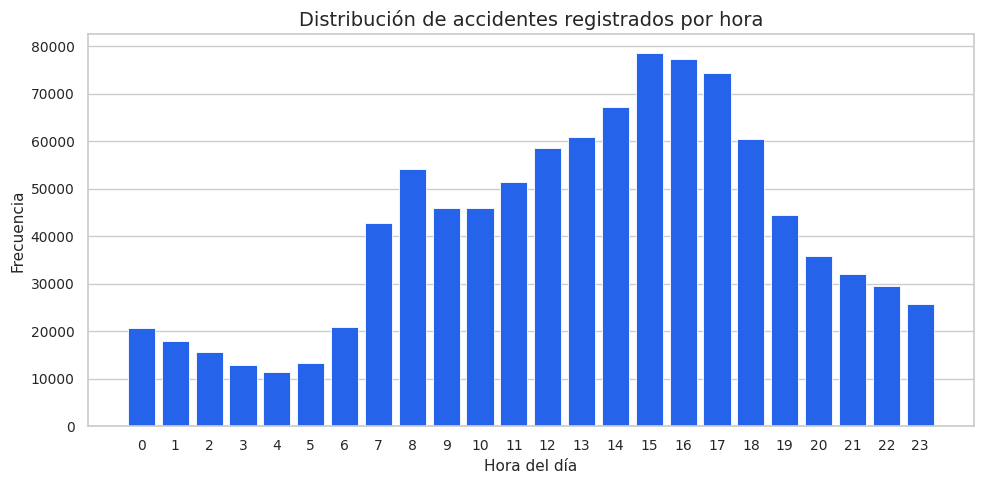

In [17]:
hour_counts = df_time_env["CRASH_HOUR"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(
    hour_counts.index,
    hour_counts.values,
    color=PALETTE[0],
    edgecolor="white",
    linewidth=0.6,
)
ax.set_title("Distribución de accidentes registrados por hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Frecuencia")
ax.set_xticks(range(24))
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

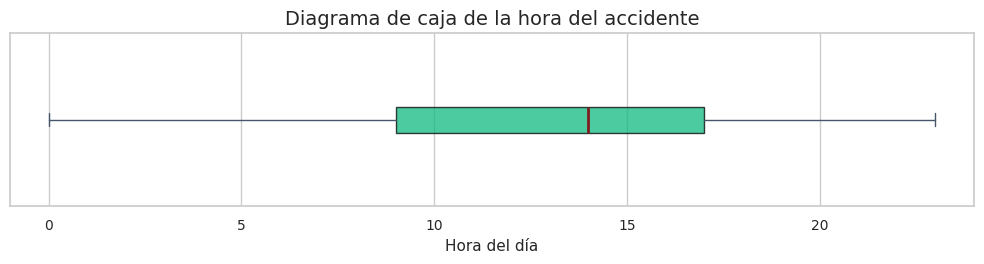

In [18]:
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.boxplot(
    df_time_env["CRASH_HOUR"],
    vert=False,
    patch_artist=True,
    boxprops={"facecolor": PALETTE[2], "alpha": 0.75},
    medianprops={"color": "#7F1D1D", "linewidth": 2},
    whiskerprops={"color": "#475569"},
    capprops={"color": "#475569"},
)
ax.set_title("Diagrama de caja de la hora del accidente")
ax.set_xlabel("Hora del día")
ax.set_yticks([])
ax.set_xlim(-1, 24)
fig.tight_layout()
plt.show()

### Interpretación

Después de excluir categorías ambientales no informativas, la frecuencia máxima corresponde a las **15:00**, con **78,537 registros**. Las horas 15:00, 16:00 y 17:00 concentran buena parte de los accidentes, mientras que la madrugada presenta las frecuencias más bajas, especialmente entre las 03:00 y las 05:00.

Este patrón es compatible con diferencias en la movilidad y la exposición al tránsito, pero el dataset no contiene el volumen de vehículos circulando por hora; por tanto, no permite concluir que una hora sea intrínsecamente más peligrosa.

In [19]:
day_freq = df_time_env["CRASH_DAY_OF_WEEK"].value_counts().sort_index()

day_freq

CRASH_DAY_OF_WEEK
1    122882
2    136757
3    142769
4    143184
5    144893
6    161385
7    145623
Name: count, dtype: Int64

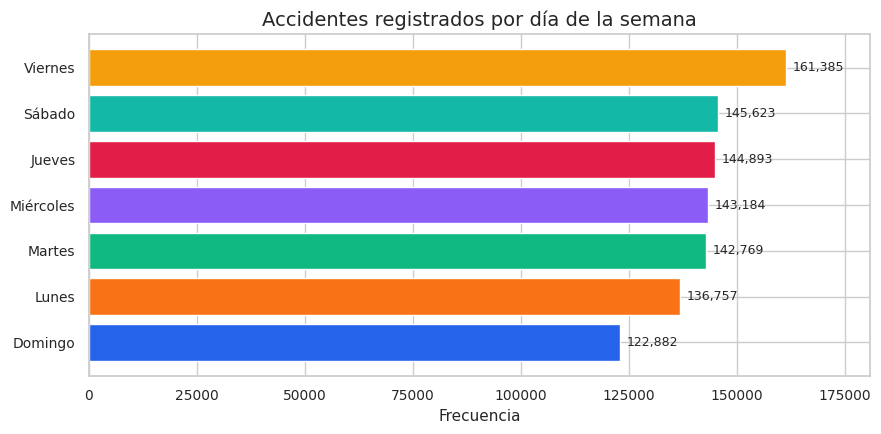

In [20]:
day_labels = {
    1: "Domingo", 2: "Lunes", 3: "Martes", 4: "Miércoles",
    5: "Jueves", 6: "Viernes", 7: "Sábado",
}
day_counts = day_freq.rename(index=day_labels).sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(day_counts.index, day_counts.values, color=PALETTE[:len(day_counts)])
ax.set_title("Accidentes registrados por día de la semana")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for idx, value in enumerate(day_counts.values):
    ax.text(value + day_counts.max() * 0.01, idx, f"{value:,.0f}", va="center", fontsize=9)
ax.set_xlim(0, day_counts.max() * 1.12)
fig.tight_layout()
plt.show()

### Interpretación

La frecuencia no es uniforme durante la semana. En los códigos del dataset, los valores **6 y 7** presentan las mayores frecuencias, mientras que el código **1** presenta la menor. Conviene mostrar las etiquetas oficiales de los días en una versión posterior del gráfico para evitar interpretar los códigos numéricos sin contexto.

La diferencia observada describe el número de registros y puede estar relacionada con patrones de movilidad, pero no constituye por sí sola una comparación de riesgo entre días.

In [21]:
month_freq = df_time_env["CRASH_MONTH"].value_counts().sort_index()

month_freq

CRASH_MONTH
1     75998
2     74030
3     78798
4     77838
5     90476
6     90541
7     90752
8     84697
9     85343
10    88879
11    79738
12    80403
Name: count, dtype: Int64

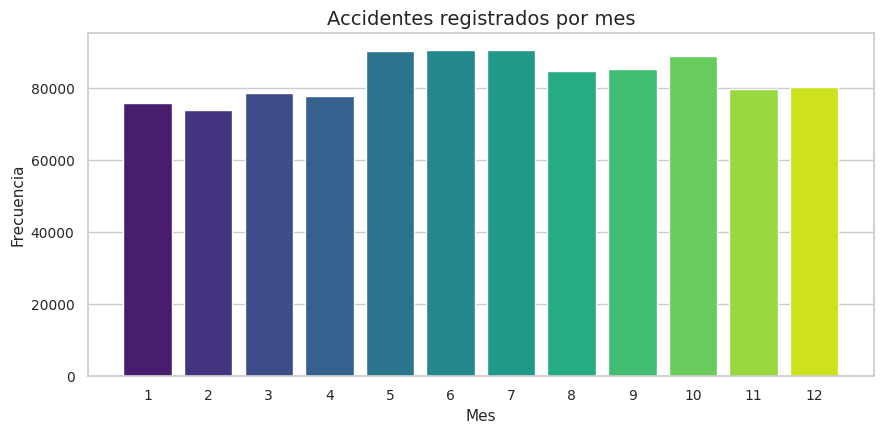

In [22]:
month_counts = month_freq.sort_index()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(month_counts.index.astype(str), month_counts.values, color=sns.color_palette("viridis", 12))
ax.set_title("Accidentes registrados por mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Frecuencia")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

### Interpretación

Los accidentes aparecen durante todos los meses. Mayo y octubre presentan algunas de las frecuencias más altas, mientras que febrero y abril se encuentran entre las más bajas en esta extracción. Las diferencias son moderadas y no se observa una concentración exclusiva en un único mes.

Como los meses no tienen exactamente la misma cantidad de días y no se dispone de exposición al tránsito, estas frecuencias deben interpretarse como conteos descriptivos.

In [23]:
weather_freq = df_time_env["WEATHER_CONDITION"].value_counts()

weather_freq

WEATHER_CONDITION
CLEAR                       837802
RAIN                         88174
SNOW                         34285
CLOUDY/OVERCAST              31113
FREEZING RAIN/DRIZZLE         2480
FOG/SMOKE/HAZE                1604
SLEET/HAIL                    1213
BLOWING SNOW                   619
SEVERE CROSS WIND GATE         182
BLOWING SAND, SOIL, DIRT        21
Name: count, dtype: int64

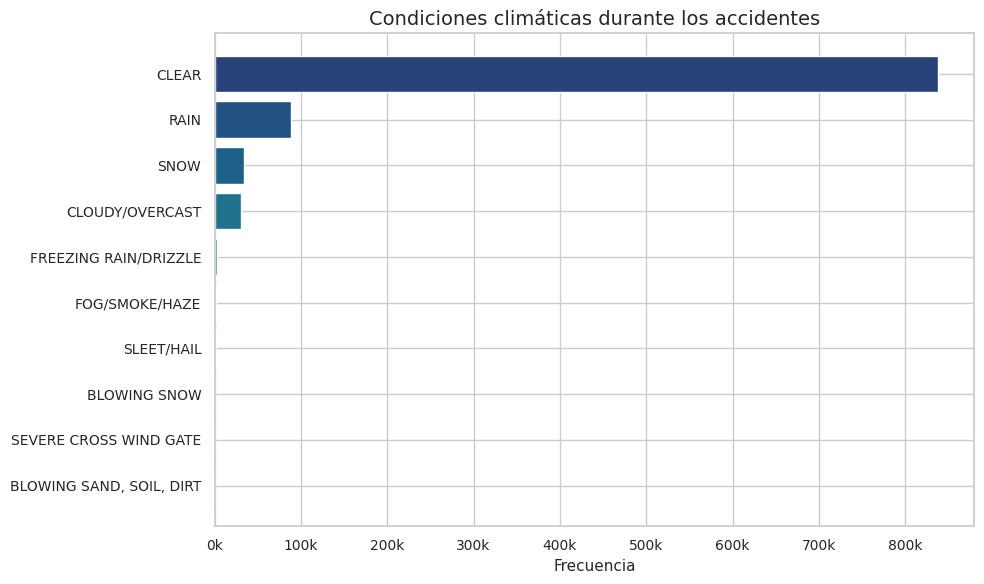

In [24]:
weather_counts = weather_freq.sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(weather_counts.index, weather_counts.values, color=sns.color_palette("crest", len(weather_counts)))
ax.set_title("Condiciones climáticas durante los accidentes")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, position: f"{value / 1_000:,.0f}k")
fig.tight_layout()
plt.show()

### Interpretación

La mayoría de los accidentes ocurrió bajo condiciones climáticas despejadas (CLEAR), representando la categoría más frecuente del conjunto de datos.

Las condiciones de lluvia (RAIN) ocupan el segundo lugar, seguidas por nieve (SNOW) y cielo nublado (CLOUDY/OVERCAST).

Es importante señalar que una mayor cantidad de accidentes en condiciones despejadas no implica necesariamente que estas condiciones sean más peligrosas, sino que probablemente corresponden a las condiciones climáticas más frecuentes durante la circulación diaria de vehículos.

Los resultados muestran que los accidentes pueden ocurrir bajo cualquier condición climática, aunque predominan en escenarios de clima favorable.

In [25]:
lighting_freq = df_time_env["LIGHTING_CONDITION"].value_counts()

lighting_freq

LIGHTING_CONDITION
DAYLIGHT                  678464
DARKNESS, LIGHTED ROAD    225749
DARKNESS                   46675
DUSK                       29234
DAWN                       17371
Name: count, dtype: int64

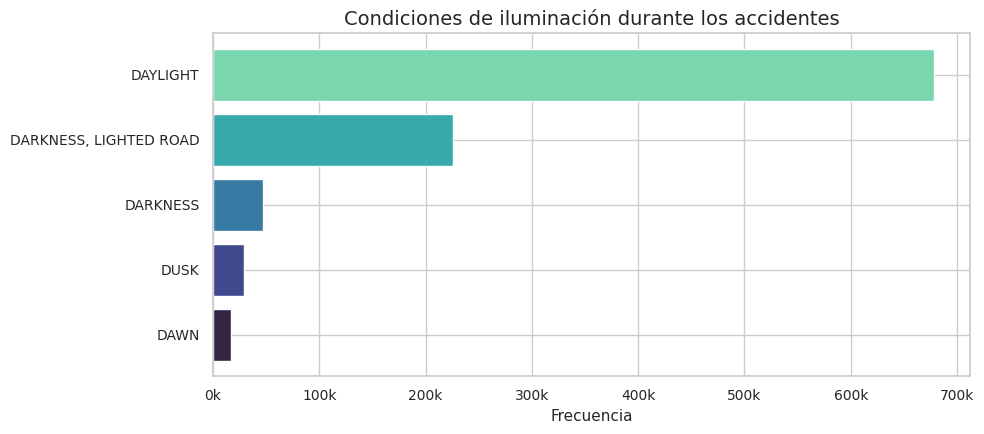

In [26]:
lighting_counts = lighting_freq.sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(lighting_counts.index, lighting_counts.values, color=sns.color_palette("mako", len(lighting_counts)))
ax.set_title("Condiciones de iluminación durante los accidentes")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(lambda value, position: f"{value / 1_000:,.0f}k")
fig.tight_layout()
plt.show()

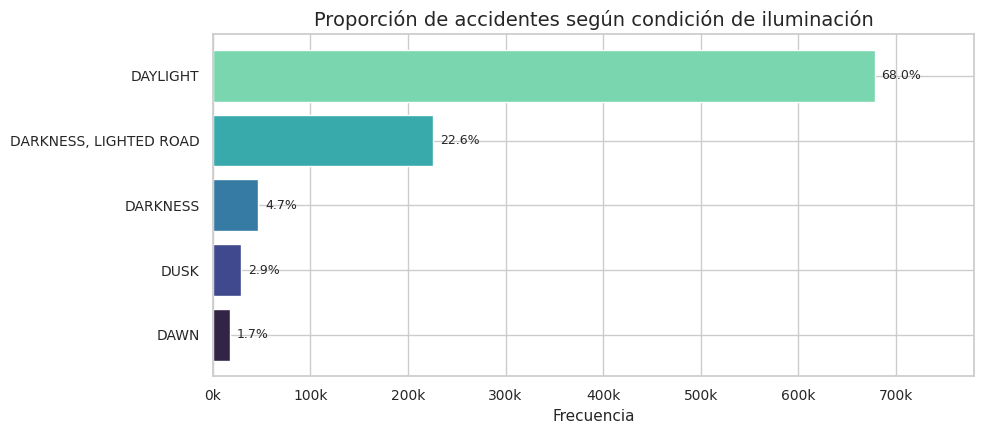

In [27]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(lighting_counts.index, lighting_counts.values, color=sns.color_palette("mako", len(lighting_counts)))
ax.set_title("Proporción de accidentes según condición de iluminación")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for idx, value in enumerate(lighting_counts.values):
    pct = value / lighting_counts.sum() * 100
    ax.text(value + lighting_counts.max() * 0.01, idx, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, lighting_counts.max() * 1.15)
ax.xaxis.set_major_formatter(lambda value, position: f"{value / 1_000:,.0f}k")
fig.tight_layout()
plt.show()

### Interpretación

La categoría más frecuente es **DAYLIGHT**, seguida de **DARKNESS, LIGHTED ROAD**. DAWN y DUSK presentan menos registros. La predominancia de luz natural no implica menor riesgo: probablemente también refleja que una mayor parte de los desplazamientos ocurre durante el día. Para medir peligrosidad sería necesario incorporar exposición o comparar tasas.

## Conclusiones de las tablas de frecuencia y gráficos

Los registros se concentran principalmente en la tarde, especialmente alrededor de las 15:00–17:00, y las frecuencias más altas de la semana se observan en los códigos 6 y 7. Los accidentes aparecen durante todo el año, con variaciones moderadas entre meses.

La mayoría de los registros corresponde a clima despejado y luz natural. Estos resultados no deben interpretarse como evidencia de que el clima despejado o la luz natural sean más peligrosos: son también condiciones probablemente más comunes. El análisis descriptivo identifica patrones de frecuencia, no tasas de riesgo.

# Probabilidades simples

Una probabilidad puede interpretarse como la proporción de veces que ocurre un determinado evento dentro del conjunto de datos.

A continuación se calcularán algunas probabilidades relacionadas con las condiciones ambientales y temporales de los accidentes.


### Probabilidad de que un accidente ocurra bajo condiciones de lluvia

Se calcula la probabilidad de que un accidente registrado haya ocurrido cuando la condición climática era lluvia (RAIN).

In [28]:
p_rain = (
    df_time_env["WEATHER_CONDITION"] == "RAIN"
).mean()

print("Probabilidad de accidente con lluvia")
print(f"Valor decimal: {p_rain:.4f}")
print(f"Porcentaje: {p_rain*100:.2f}%")

Probabilidad de accidente con lluvia
Valor decimal: 0.0884
Porcentaje: 8.84%


### Probabilidad de que un accidente ocurra en condiciones de oscuridad

Se calcula la probabilidad de que un accidente ocurra durante la noche, considerando tanto vías iluminadas como no iluminadas.

In [29]:
p_dark = (
    df_time_env["LIGHTING_CONDITION"]
    .isin([
        "DARKNESS",
        "DARKNESS, LIGHTED ROAD"
    ])
).mean()

print("Probabilidad de accidente en condiciones de oscuridad")
print(f"Valor decimal: {p_dark:.4f}")
print(f"Porcentaje: {p_dark*100:.2f}%")

Probabilidad de accidente en condiciones de oscuridad
Valor decimal: 0.2731
Porcentaje: 27.31%


### Probabilidad de accidente durante horas pico

Se analiza la probabilidad de que un accidente ocurra entre las 14:00 y las 18:00 horas, intervalo que presentó las mayores frecuencias en el análisis descriptivo.

In [30]:
p_peak = (
    df_time_env["CRASH_HOUR"]
    .between(14, 18)
).mean()

print("Probabilidad de accidente entre las 14:00 y las 18:00 horas")
print(f"Valor decimal: {p_peak:.4f}")
print(f"Porcentaje: {p_peak*100:.2f}%")

Probabilidad de accidente entre las 14:00 y las 18:00 horas
Valor decimal: 0.3586
Porcentaje: 35.86%


### Probabilidad conjunta de lluvia y oscuridad

Se calcula la probabilidad de que un accidente haya ocurrido simultáneamente bajo condiciones de lluvia y oscuridad.

In [31]:
joint_prob = (
    (
        df_time_env["WEATHER_CONDITION"] == "RAIN"
    )
    &
    (
        df_time_env["LIGHTING_CONDITION"]
        .isin([
            "DARKNESS",
            "DARKNESS, LIGHTED ROAD"
        ])
    )
).mean()

print("Probabilidad conjunta de lluvia y oscuridad")
print(f"Valor decimal: {joint_prob:.4f}")
print(f"Porcentaje: {joint_prob*100:.2f}%")

Probabilidad conjunta de lluvia y oscuridad
Valor decimal: 0.0343
Porcentaje: 3.43%


### Probabilidad condicional de lluvia dado que existe oscuridad

Se calcula la probabilidad de que estuviera lloviendo, sabiendo que el accidente ocurrió en condiciones de oscuridad.

In [32]:
dark_df = df_time_env[
    df_time_env["LIGHTING_CONDITION"]
    .isin([
        "DARKNESS",
        "DARKNESS, LIGHTED ROAD"
    ])
]

conditional_prob = (
    dark_df["WEATHER_CONDITION"] == "RAIN"
).mean()

print("Probabilidad condicional de lluvia dado oscuridad")
print(f"Valor decimal: {conditional_prob:.4f}")
print(f"Porcentaje: {conditional_prob*100:.2f}%")

Probabilidad condicional de lluvia dado oscuridad
Valor decimal: 0.1254
Porcentaje: 12.54%


In [33]:
prob_table = pd.DataFrame({
    "Evento": [
        "Lluvia",
        "Oscuridad",
        "Horas pico (14-18)",
        "Lluvia y oscuridad",
        "Lluvia dado oscuridad"
    ],
    "Probabilidad": [
        p_rain,
        p_dark,
        p_peak,
        joint_prob,
        conditional_prob
    ]
})

prob_table["Porcentaje"] = prob_table["Probabilidad"] * 100

prob_table

,Evento,Probabilidad,Porcentaje
0,Lluvia,0.0884,8.8396
1,Oscuridad,0.2731,27.3109
2,Horas pico (14-18),0.3586,35.8584
3,Lluvia y oscuridad,0.0343,3.4252
4,Lluvia dado oscuridad,0.1254,12.5415


### Interpretación de los resultados probabilísticos

En la muestra depurada, las probabilidades observadas permiten resumir la composición de los registros:

- **Lluvia:** 8.84%.
- **Oscuridad:** 27.31%.
- **Entre 14:00 y 18:00:** 35.86%.
- **Lluvia y oscuridad simultáneamente:** 3.43%.
- **Lluvia dado que hay oscuridad:** 12.54%.

La última cifra es una probabilidad condicional: el denominador son únicamente los accidentes ocurridos en oscuridad. Ninguna de estas cantidades mide riesgo causal, porque no incorpora cuántos desplazamientos ocurrieron bajo cada condición.

# Parte 2 - Velocidad e Infraestructura


## Análisis de Velocidad e Infraestructura en Accidentes de Tránsito de Chicago

### Descripción

En esta sección se analizarán variables relacionadas con las características de la vía y los dispositivos de control presentes en el lugar del accidente, así como el límite de velocidad establecido.

Las variables seleccionadas son:

- POSTED_SPEED_LIMIT
- TRAFFICWAY_TYPE
- TRAFFIC_CONTROL_DEVICE

El objetivo es identificar patrones en los límites de velocidad y en los tipos de vía y control asociados a los accidentes, para comprender mejor cómo la infraestructura influye en la ocurrencia de siniestros.

## Selección de variables para el análisis

Del conjunto de datos original, seleccionamos las tres variables asignadas para esta sección.

In [34]:
# Seleccionar las columnas de interes
selected_cols_p2 = [
    "POSTED_SPEED_LIMIT",
    "TRAFFICWAY_TYPE",
    "TRAFFIC_CONTROL_DEVICE"
]

df_infra = df[selected_cols_p2].copy()

# Verificar las primeras filas
df_infra.head()

,POSTED_SPEED_LIMIT,TRAFFICWAY_TYPE,TRAFFIC_CONTROL_DEVICE
0,30,DIVIDED - W/MEDIAN BARRIER,NO CONTROLS
1,0,NOT DIVIDED,TRAFFIC SIGNAL
2,30,NOT DIVIDED,TRAFFIC SIGNAL
3,5,PARKING LOT,NO CONTROLS
4,30,NOT DIVIDED,NO CONTROLS


## Verificación de valores faltantes

Revisamos si existen valores nulos en las variables seleccionadas.

In [35]:
# Conteo de valores nulos
df_infra.isnull().sum()

POSTED_SPEED_LIMIT        0
TRAFFICWAY_TYPE           0
TRAFFIC_CONTROL_DEVICE    0
dtype: int64

In [36]:
# Porcentaje de nulos
missing_p2 = pd.DataFrame({
    "Valores Nulos": df_infra.isnull().sum(),
    "Porcentaje": round(df_infra.isnull().mean() * 100, 2)
})
missing_p2

,Valores Nulos,Porcentaje
POSTED_SPEED_LIMIT,0,0.0000
TRAFFICWAY_TYPE,0,0.0000
TRAFFIC_CONTROL_DEVICE,0,0.0000


**Nota de calidad de datos:** las tres variables no presentan valores nulos en la extracción mostrada. El tamaño efectivo debe tomarse de `df_infra.shape[0]` y no escribirse manualmente, porque puede cambiar al actualizar el CSV.

## Clasificación de variables

De acuerdo con los conceptos estadísticos, clasificamos las variables de la siguiente manera:

| Variable | Clasificación | Justificación |
|----------|---------------|----------------|
| POSTED_SPEED_LIMIT | Cuantitativa discreta | Toma valores enteros (10, 20, 30, 40, etc.) que representan millas por hora. No admite decimales significativos. |
| TRAFFICWAY_TYPE | Cualitativa nominal | Describe el tipo de vía (ej. "STREET", "HIGHWAY", "ALLEY") sin un orden inherente. |
| TRAFFIC_CONTROL_DEVICE | Cualitativa nominal | Describe el dispositivo de control presente (ej. "TRAFFIC SIGNAL", "STOP SIGN", "NO CONTROLS") sin orden natural. |

## Tablas de frecuencia

Construimos tablas de frecuencia absoluta, relativa y porcentual para cada variable cualitativa y para la cuantitativa discreta (límite de velocidad).

In [37]:
# Funcion auxiliar para generar tabla de frecuencias
def freq_table(series, name):
    freq_abs = series.value_counts(dropna=False)
    freq_rel = series.value_counts(dropna=False, normalize=True)
    freq_perc = freq_rel * 100
    table = pd.DataFrame({
        'Frecuencia Absoluta': freq_abs,
        'Frecuencia Relativa': freq_rel,
        'Frecuencia Porcentual (%)': freq_perc
    })
    print(f"\n--- Tabla de frecuencia: {name} ---")
    print(table.head(10))  # Mostrar solo las 10 categorias mas frecuentes
    return table

In [38]:
speed_table = freq_table(df_infra['POSTED_SPEED_LIMIT'], 'Límite de velocidad')


--- Tabla de frecuencia: Límite de velocidad ---
                    Frecuencia Absoluta  Frecuencia Relativa  \
POSTED_SPEED_LIMIT                                             
30                               797197               0.7382   
25                                71350               0.0661   
35                                68136               0.0631   
20                                45782               0.0424   
15                                38317               0.0355   
10                                25997               0.0241   
40                                10424               0.0097   
0                                  7893               0.0073   
45                                 6945               0.0064   
5                                  5541               0.0051   

                    Frecuencia Porcentual (%)  
POSTED_SPEED_LIMIT                             
30                                    73.8227  
25                                   

In [39]:
way_table = freq_table(df_infra['TRAFFICWAY_TYPE'], 'Tipo de vía')


--- Tabla de frecuencia: Tipo de vía ---
                                 Frecuencia Absoluta  Frecuencia Relativa  \
TRAFFICWAY_TYPE                                                             
NOT DIVIDED                                   460141               0.4261   
DIVIDED - W/MEDIAN (NOT RAISED)               167152               0.1548   
ONE-WAY                                       134703               0.1247   
FOUR WAY                                       84322               0.0781   
PARKING LOT                                    72690               0.0673   
DIVIDED - W/MEDIAN BARRIER                     59766               0.0553   
OTHER                                          28965               0.0268   
ALLEY                                          17721               0.0164   
T-INTERSECTION                                 16753               0.0155   
UNKNOWN                                        13115               0.0121   

                                 

In [40]:
control_table = freq_table(df_infra['TRAFFIC_CONTROL_DEVICE'], 'Dispositivo de control')


--- Tabla de frecuencia: Dispositivo de control ---
                          Frecuencia Absoluta  Frecuencia Relativa  \
TRAFFIC_CONTROL_DEVICE                                               
NO CONTROLS                            606014               0.5612   
TRAFFIC SIGNAL                         298950               0.2768   
STOP SIGN/FLASHER                      107219               0.0993   
UNKNOWN                                 51377               0.0476   
OTHER                                    7471               0.0069   
YIELD                                    1683               0.0016   
OTHER REG. SIGN                          1254               0.0012   
LANE USE MARKING                         1226               0.0011   
PEDESTRIAN CROSSING SIGN                  907               0.0008   
OTHER WARNING SIGN                        821               0.0008   

                          Frecuencia Porcentual (%)  
TRAFFIC_CONTROL_DEVICE                              

## Medidas estadísticas para POSTED_SPEED_LIMIT

Calculamos media, mediana, moda y desviación estándar.

In [41]:
# Extraer la variable
speed = df_infra['POSTED_SPEED_LIMIT'].dropna()

media_speed = speed.mean()
mediana_speed = speed.median()
moda_speed = speed.mode()[0] if not speed.mode().empty else np.nan
desviacion_speed = speed.std()

stats_speed = pd.DataFrame({
    "Medida": ["Media", "Mediana", "Moda", "Desviación estándar"],
    "Valor": [media_speed, mediana_speed, moda_speed, desviacion_speed]
})
stats_speed

,Medida,Valor
0,Media,28.4205
1,Mediana,30.0000
2,Moda,30.0000
3,Desviación estándar,6.0174


## Probabilidades básicas

Calculamos probabilidades simples relacionadas con el límite de velocidad y el tipo de vía.

In [42]:
total_accidentes = len(df_infra)

# Probabilidad de accidente en vias con limite > 40 mph
mayor_40 = (df_infra['POSTED_SPEED_LIMIT'] > 40).sum()
prob_mayor_40 = mayor_40 / total_accidentes

# Probabilidad de accidente en vias con limite > 50 mph
mayor_50 = (df_infra['POSTED_SPEED_LIMIT'] > 50).sum()
prob_mayor_50 = mayor_50 / total_accidentes

# Probabilidad de accidente en un determinado tipo de via (ejemplo: 'STREET')
# Primero veremos las categorias mas comunes
print("Tipos de vía más frecuentes:")
print(df_infra['TRAFFICWAY_TYPE'].value_counts().head(5))

# Elegimos 'STREET' como ejemplo
tipo_ejemplo = 'STREET'
if tipo_ejemplo in df_infra['TRAFFICWAY_TYPE'].values:
    prob_tipo = (df_infra['TRAFFICWAY_TYPE'] == tipo_ejemplo).sum() / total_accidentes
else:
    # Si 'STREET' no existe, usamos la categoría mas común
    tipo_ejemplo = df_infra['TRAFFICWAY_TYPE'].value_counts().index[0]
    prob_tipo = (df_infra['TRAFFICWAY_TYPE'] == tipo_ejemplo).sum() / total_accidentes

print("\n--- Probabilidades ---")
print(f"P(límite > 40 mph) = {prob_mayor_40:.4f} ({prob_mayor_40*100:.2f}%)")
print(f"P(límite > 50 mph) = {prob_mayor_50:.4f} ({prob_mayor_50*100:.2f}%)")
print(f"P(tipo de vía = {tipo_ejemplo}) = {prob_tipo:.4f} ({prob_tipo*100:.2f}%)")

Tipos de vía más frecuentes:


TRAFFICWAY_TYPE
NOT DIVIDED                        460141
DIVIDED - W/MEDIAN (NOT RAISED)    167152
ONE-WAY                            134703
FOUR WAY                            84322
PARKING LOT                         72690
Name: count, dtype: int64

--- Probabilidades ---
P(límite > 40 mph) = 0.0079 (0.79%)
P(límite > 50 mph) = 0.0011 (0.11%)
P(tipo de vía = NOT DIVIDED) = 0.4261 (42.61%)


## Gráficos representativos

Construimos gráficos de barras para el límite de velocidad y diagramas circulares para las variables categóricas.

### Distribución de accidentes por límite de velocidad

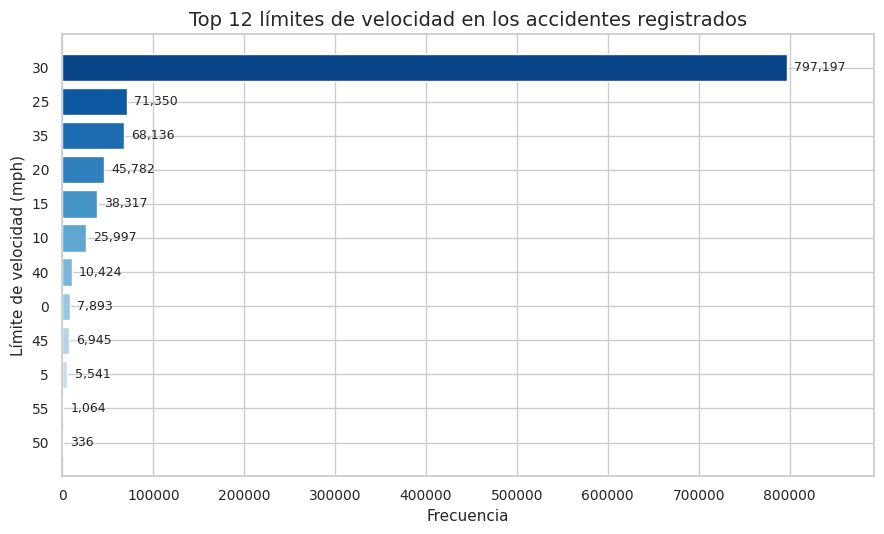

In [43]:
speed_counts = df_infra["POSTED_SPEED_LIMIT"].value_counts()
top_speed = speed_counts.nlargest(12).sort_values()

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top_speed.index.astype(str), top_speed.values, color=sns.color_palette("Blues", len(top_speed)))
ax.set_title("Top 12 límites de velocidad en los accidentes registrados")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("Límite de velocidad (mph)")
for idx, value in enumerate(top_speed.values):
    ax.text(value + top_speed.max() * 0.01, idx, f"{value:,.0f}", va="center", fontsize=9)
ax.set_xlim(0, top_speed.max() * 1.12)
fig.tight_layout()
plt.show()

### Diagrama circular para tipo de vía (top 5 categorías)

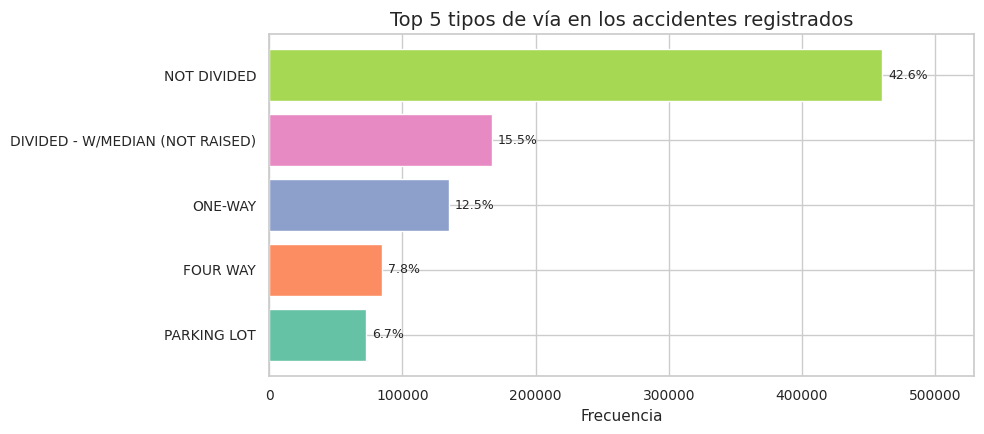

In [44]:
top_ways = df_infra["TRAFFICWAY_TYPE"].value_counts().nlargest(5).sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(top_ways.index, top_ways.values, color=sns.color_palette("Set2", len(top_ways)))
ax.set_title("Top 5 tipos de vía en los accidentes registrados")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for idx, value in enumerate(top_ways.values):
    pct = value / df_infra.shape[0] * 100
    ax.text(value + top_ways.max() * 0.01, idx, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, top_ways.max() * 1.15)
fig.tight_layout()
plt.show()

### Diagrama circular para dispositivo de control (top 5 categorías)

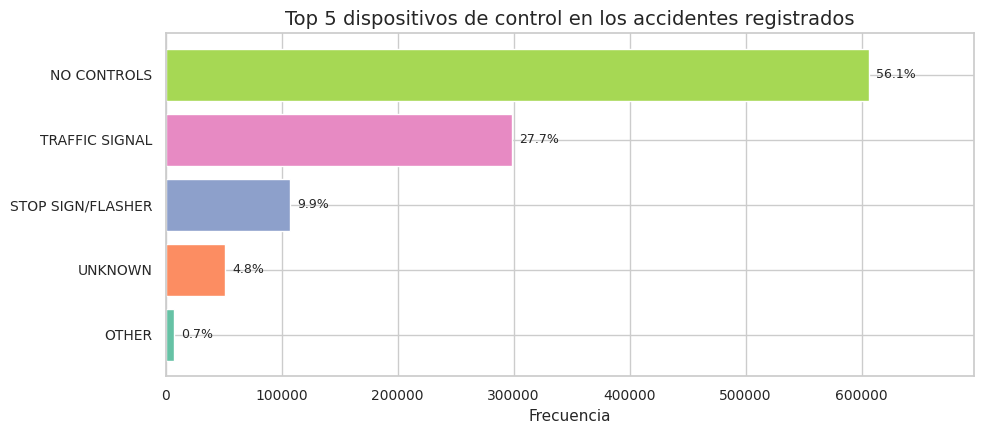

In [45]:
top_controls = df_infra["TRAFFIC_CONTROL_DEVICE"].value_counts().nlargest(5).sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.barh(top_controls.index, top_controls.values, color=sns.color_palette("Set2", len(top_controls)))
ax.set_title("Top 5 dispositivos de control en los accidentes registrados")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for idx, value in enumerate(top_controls.values):
    pct = value / df_infra.shape[0] * 100
    ax.text(value + top_controls.max() * 0.01, idx, f"{pct:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, top_controls.max() * 1.15)
fig.tight_layout()
plt.show()

## Interpretación de resultados: velocidad e infraestructura

- El límite de velocidad tiene media **28.42 mph**, mediana **30 mph** y moda **30 mph**. La moda muestra que 30 mph es el límite más frecuente entre los registros, no que sea el límite más peligroso.
- La desviación estándar es **6.02 mph**. La media y la mediana son cercanas, pero conviene revisar el histograma porque los límites de velocidad son discretos y la distribución está muy concentrada en 30 mph.
- El **0.79%** de los registros corresponde a límites superiores a 40 mph y el **0.11%** a límites superiores a 50 mph.
- El tipo de vía más frecuente es **NOT DIVIDED**, con **42.61%** de los registros.

Estos resultados describen dónde se registraron accidentes. No permiten concluir que una infraestructura cause más accidentes, porque faltan denominadores como kilómetros de vía, flujo vehicular y número de vehículos expuestos.

# Parte 3 - Lesiones y Severidad


## Lesiones y Severidad

### Descripción

En esta sección se analizarán variables relacionadas con las consecuencias físicas y las lesiones ocasionadas por los accidentes de tránsito.

Las variables seleccionadas son:

- INJURIES_TOTAL
- INJURIES_FATAL
- MOST_SEVERE_INJURY

El objetivo es determinar el impacto físico ocacionados en acidentes viales mediante el cálculo de probabilidades, identificando específicamente el riesgo de que un accidente produzca al menos un lesionado, una fatalidad o sea catalogado como grave.

In [46]:
selected_columns_p3 = [
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "MOST_SEVERE_INJURY"
]

df_injuries = df[selected_columns_p3].copy()

df_injuries.head()

,INJURIES_TOTAL,INJURIES_FATAL,MOST_SEVERE_INJURY
0,0.0000,0.0000,NO INDICATION OF INJURY
1,0.0000,0.0000,NO INDICATION OF INJURY
2,0.0000,0.0000,NO INDICATION OF INJURY
3,0.0000,0.0000,NO INDICATION OF INJURY
4,0.0000,0.0000,NO INDICATION OF INJURY


## Contrato de variables de lesiones

Las medidas de lesiones ya vienen tipadas desde dbt y los valores
faltantes de las medidas se representan como cero en la fact. La
dimensión de severidad aporta la categoría `Unknown` cuando el origen
no informa una etiqueta.


In [47]:
df_injuries.isnull().sum()

INJURIES_TOTAL        0
INJURIES_FATAL        0
MOST_SEVERE_INJURY    0
dtype: int64

In [48]:
missing = pd.DataFrame({
    "Valores Nulos": df_injuries.isnull().sum(),
    "Porcentaje": round(df_injuries.isnull().mean() * 100, 2)
})

missing

,Valores Nulos,Porcentaje
INJURIES_TOTAL,0,0.0000
INJURIES_FATAL,0,0.0000
MOST_SEVERE_INJURY,0,0.0000


## Verificación de valores faltantes

Se detectaron valores nulos en las tres variables: **2,282** en `INJURIES_TOTAL`, **2,282** en `INJURIES_FATAL` y **2,297** en `MOST_SEVERE_INJURY`. Se eliminan las filas con algún valor faltante para mantener un denominador coherente en las tablas y probabilidades de esta sección.

La eliminación reduce ligeramente el tamaño de la muestra; por eso se reporta el tamaño efectivo en el código y se debe evitar usar el total original en los cálculos.

In [49]:
df_injuries_clean = df_injuries.copy()

print("[Verificación del contrato Gold]")
print(df_injuries_clean.isnull().sum())


[Verificación del contrato Gold]
INJURIES_TOTAL        0
INJURIES_FATAL        0
MOST_SEVERE_INJURY    0
dtype: int64


## Verificación de consistencia de los datos

Además de revisar la existencia de valores faltantes, es importante comprobar que las variables numéricas se encuentren dentro de rangos válidos.

Esto permite detectar posibles errores de captura o registros inconsistentes antes de realizar el análisis estadístico.

In [50]:
df_injuries[["INJURIES_TOTAL", "INJURIES_FATAL", "MOST_SEVERE_INJURY"]].describe()

,INJURIES_TOTAL,INJURIES_FATAL
count,"1,079,880.0000","1,079,880.0000"
mean,0.1997,0.0011
std,0.5804,0.0368
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
max,21.0000,4.0000


## Clasificación de variables

Las variables seleccionadas para el análisis fueron clasificadas de acuerdo con los conceptos estudiados en Estadística.

| Variable | Clasificación | Justificación |
|-----------|-----------|-----------|
| INJURIES_TOTAL | Cuantitativa discreta | Representa un conteo numérico entero de la cantidad total de personas heridas. |
| INJURIES_FATAL | Cuantitativa discreta | Representa un conteo numérico entero de la cantidad de personas fallecidas. |
| MOST_SEVERE_INJURY | Cualitativa ordinal | Describe categorías de gravedad de la lesión siguiendo un orden o escala jerárquica natural. |

In [51]:
df_injuries.dtypes

INJURIES_TOTAL        float64
INJURIES_FATAL        float64
MOST_SEVERE_INJURY     object
dtype: object

# Tablas de frecuencia

crearemos las tablas de frecuencia absoluta y el porcentaje para cada una de las variables analizadas.

Estas tablas sirven para hacercalculos de las probabilidades, donde el porcentaje de cada fila representa la probabilidad de que un accidente elegido al azar presente esas características específicas de gravedad.

In [52]:
frec_abs_total = df_injuries_clean['INJURIES_TOTAL'].value_counts()
frec_porc_total = df_injuries_clean['INJURIES_TOTAL'].value_counts(normalize=True) * 100

tabla_total = pd.DataFrame({
    'Frecuencia Absoluta': frec_abs_total,
    'Porcentaje': frec_porc_total.round(2)
}).sort_index()


frec_abs_fatal = df_injuries_clean['INJURIES_FATAL'].value_counts()
frec_porc_fatal = df_injuries_clean['INJURIES_FATAL'].value_counts(normalize=True) * 100

tabla_fatal = pd.DataFrame({
    'Frecuencia Absoluta': frec_abs_fatal,
    'Porcentaje': frec_porc_fatal.round(2)
}).sort_index()


frec_abs_severe = df_injuries_clean['MOST_SEVERE_INJURY'].value_counts()
frec_porc_severe = df_injuries_clean['MOST_SEVERE_INJURY'].value_counts(normalize=True) * 100

tabla_severe = pd.DataFrame({
    'Frecuencia Absoluta': frec_abs_severe,
    'Porcentaje': frec_porc_severe.round(2)
})
print (tabla_total)
print ("----------------------------------------------")
print (tabla_fatal)
print ("----------------------------------------------")
print (tabla_severe)

                Frecuencia Absoluta  Porcentaje
INJURIES_TOTAL                                 
0.0000                       923937     85.5600
1.0000                       116889     10.8200
2.0000                        26390      2.4400
3.0000                         8022      0.7400
4.0000                         2857      0.2600
5.0000                         1047      0.1000
6.0000                          410      0.0400
7.0000                          172      0.0200
8.0000                           66      0.0100
9.0000                           34      0.0000
10.0000                          16      0.0000
11.0000                          10      0.0000
12.0000                           7      0.0000
13.0000                           3      0.0000
14.0000                           2      0.0000
15.0000                           8      0.0000
16.0000                           2      0.0000
17.0000                           1      0.0000
18.0000                           1     

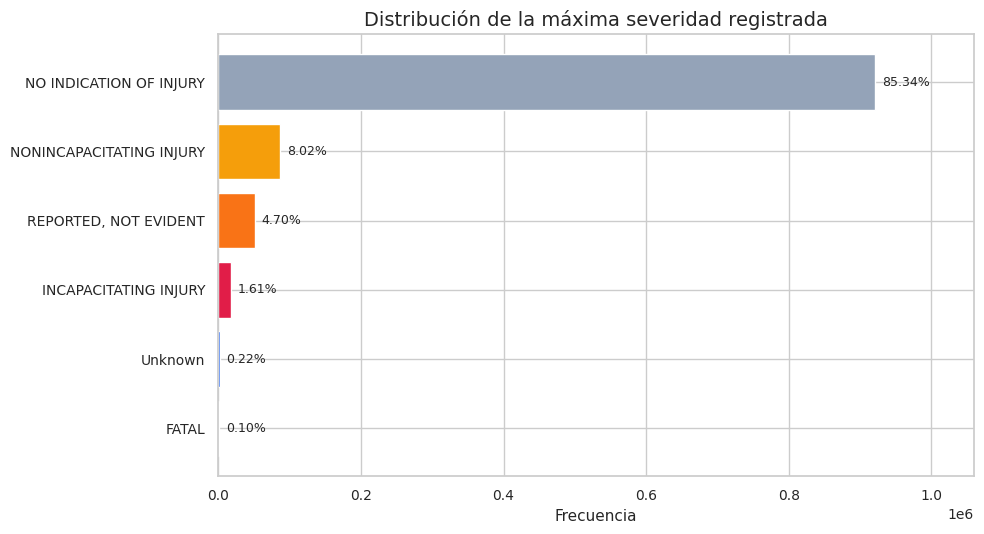

In [53]:
data_gravity = df_injuries_clean["MOST_SEVERE_INJURY"].value_counts()
data_gravity = data_gravity.reindex(data_gravity.sort_values().index)
colors = [SEVERITY_COLORS.get(category, PALETTE[0]) for category in data_gravity.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(data_gravity.index, data_gravity.values, color=colors)
ax.set_title("Distribución de la máxima severidad registrada")
ax.set_xlabel("Frecuencia")
ax.set_ylabel("")
for idx, value in enumerate(data_gravity.values):
    pct = value / data_gravity.sum() * 100
    ax.text(value + data_gravity.max() * 0.01, idx, f"{pct:.2f}%", va="center", fontsize=9)
ax.set_xlim(0, data_gravity.max() * 1.15)
fig.tight_layout()
plt.show()

## Interpretación de las tablas de frecuencia

- **NO INDICATION OF INJURY (85.53%):** es la categoría más frecuente en `MOST_SEVERE_INJURY`.
- **NONINCAPACITATING INJURY (8.04%):** corresponde a lesiones no incapacitantes.
- **REPORTED, NOT EVIDENT (4.71%):** corresponde a lesiones reportadas pero no evidentes.
- **INCAPACITATING INJURY (1.62%):** corresponde a la categoría de lesión incapacitante definida por el dataset.
- **FATAL (0.10%):** es una categoría poco frecuente en los registros.

Estas proporciones describen la severidad registrada en la base y no deben traducirse automáticamente en afirmaciones sobre seguridad general de la ciudad.

#  Medidas estadísticas

Para entender mejor cómo se comportan los datos del total de lesionados, calculamos sus medidas de tendencia central y de dispersió

In [54]:
media_total = df_injuries_clean['INJURIES_TOTAL'].mean()
mediana_total = df_injuries_clean['INJURIES_TOTAL'].median()
moda_total = df_injuries_clean['INJURIES_TOTAL'].mode()[0]
std_total = df_injuries_clean['INJURIES_TOTAL'].std()
print("INJURIES_TOTAL")
print("Media:", media_total)
print("Mediana:", mediana_total)
print("Moda:", moda_total)
print("Desviación Estándar:", std_total)

print("----------------")
media_fatal = df_injuries_clean['INJURIES_FATAL'].mean()
mediana_fatal = df_injuries_clean['INJURIES_FATAL'].median()
moda_fatal = df_injuries_clean['INJURIES_FATAL'].mode()[0]
std_fatal = df_injuries_clean['INJURIES_FATAL'].std()

print("INJURIES_FATAL")
print("Media:", media_fatal)
print("Mediana:", mediana_fatal)
print("Moda:", moda_fatal)
print("Desviación Estándar:", std_fatal)

INJURIES_TOTAL
Media: 0.19967588991369412
Mediana: 0.0
Moda: 0.0
Desviación Estándar: 0.5804001231128157
----------------
INJURIES_FATAL
Media: 0.0011399414749787013
Mediana: 0.0
Moda: 0.0
Desviación Estándar: 0.03684000632814419


## Interpretación de las medidas estadísticas

- `INJURIES_TOTAL` tiene media **0.200 lesionados por accidente**, mediana **0**, moda **0** y desviación estándar **0.581**. La media es un conteo promedio, no un porcentaje.
- `INJURIES_FATAL` tiene media **0.00114 fatalidades por accidente**, mediana **0**, moda **0** y desviación estándar **0.0369**. La mayoría de los registros no presenta fatalidades, mientras que unos pocos casos elevan la dispersión.

La asimetría y la concentración de ceros hacen que la mediana y la moda sean más representativas del accidente típico que la media.

## Cuartiles y percentiles Injuries total

ara conocer la distribución por bloques de los lesionados, calculamos los cuartiles y percentiles. Debido a que el 85.75% de los datos son ceros, los resultados se concentran de la siguiente manera:

In [55]:
q1 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.25)
q2 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.50)  # Es la misma mediana
q3 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.75)

print("CUARTILES")
print("Q1 (Percentil 25):", q1)
print("Q2 (Percentil 50):", q2)
print("Q3 (Percentil 75):", q3)

p10 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.10)
p25 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.25)
p50 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.50)
p75 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.75)
p90 = df_injuries_clean['INJURIES_TOTAL'].quantile(0.90)

print("PERCENTILES")
print("Percentil 10:", p10)
print("Percentil 25:", p25)
print("Percentil 50:", p50)
print("Percentil 75:", p75)
print("Percentil 90:", p90)

CUARTILES
Q1 (Percentil 25): 0.0
Q2 (Percentil 50): 0.0
Q3 (Percentil 75): 0.0
PERCENTILES
Percentil 10: 0.0
Percentil 25: 0.0
Percentil 50: 0.0
Percentil 75: 0.0
Percentil 90: 1.0


## Interpretación de cuartiles y percentiles

Q1, Q2 y Q3 de `INJURIES_TOTAL` son **0**, por lo que al menos el 75% de los accidentes de la muestra depurada registra cero lesionados. Los percentiles 10, 25, 50 y 75 también son 0; el percentil 90 es 1.

Esto significa que el valor de corte del 90% es un lesionado: no significa que exactamente el 10% de los accidentes tenga lesiones, sino que la distribución es discreta y está fuertemente concentrada en cero. La probabilidad exacta de al menos un lesionado se calcula posteriormente y es **14.47%**.

# Probabilidad básica
- Probabilidad de que un accidente produzca al menos un
lesionado.


In [56]:
# Total de registros limpios — necesario para el cálculo de probabilidades
total = len(df_injuries_clean)
print(f'Total de registros utilizados: {total:,}')


Total de registros utilizados: 1,079,880


In [57]:
prob_un_lesionado = (df_injuries_clean['INJURIES_TOTAL'] >= 1).sum() / total
print(f"Probabilidad al menos un lesionado: {prob_un_lesionado * 100:.2f}%")

Probabilidad al menos un lesionado: 14.44%


- Probabilidad de que un accidente produzca una fatalidad.


In [58]:
prob_fatalidad = (df_injuries_clean['INJURIES_FATAL'] > 0).sum() / total
print(f"Probabilidad de fatalidad: {prob_fatalidad * 100:.2f}%")

Probabilidad de fatalidad: 0.10%


- Probabilidad de que un accidente sea catalogado como grave.

In [59]:
prob_grave = (df_injuries_clean['MOST_SEVERE_INJURY'] == 'INCAPACITATING INJURY').sum() / total
print(f"Probabilidad de accidente grave: {prob_grave * 100:.2f}%")

Probabilidad de accidente grave: 1.61%


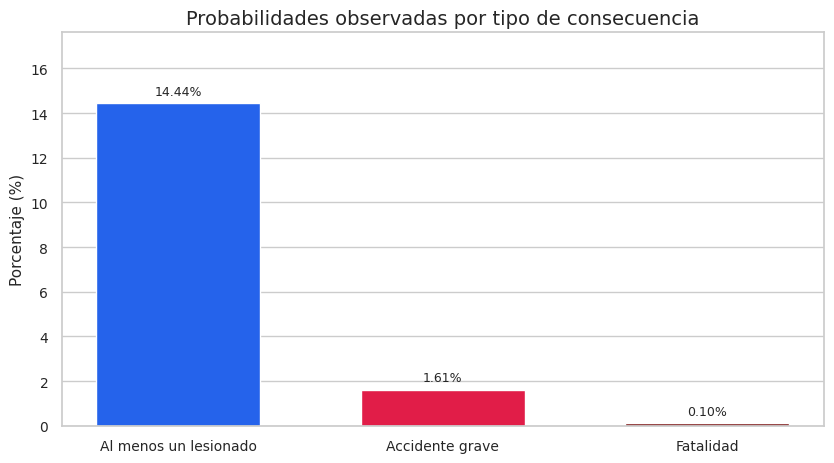

In [60]:
probabilidades = pd.DataFrame({
    "Escenario": ["Al menos un lesionado", "Accidente grave", "Fatalidad"],
    "Porcentaje (%)": [prob_un_lesionado * 100, prob_grave * 100, prob_fatalidad * 100],
})

fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = ["#2563EB", "#E11D48", "#7F1D1D"]
bars = ax.bar(probabilidades["Escenario"], probabilidades["Porcentaje (%)"], color=colors, width=0.62)
ax.set_title("Probabilidades observadas por tipo de consecuencia")
ax.set_ylabel("Porcentaje (%)")
ax.set_xlabel("")
ax.set_ylim(0, max(probabilidades["Porcentaje (%)"]) * 1.22)
for bar, value in zip(bars, probabilidades["Porcentaje (%)"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25, f"{value:.2f}%", ha="center", va="bottom", fontsize=9)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

# Interpretación de las probabilidades

- La probabilidad observada de **al menos un lesionado** es **14.47%**: aproximadamente 14 de cada 100 accidentes de la muestra registran uno o más lesionados.
- La probabilidad observada de **fatalidad** es **0.10%**: aproximadamente 1 de cada 1,000 accidentes registra al menos una fatalidad.
- La probabilidad observada de una **lesión incapacitante como máxima severidad** es **1.62%**.

Estas son proporciones dentro de los accidentes registrados y no probabilidades individuales de un conductor. Tampoco permiten concluir que la mayoría de los accidentes “solo provoca daños materiales”, porque el dataset puede tener limitaciones de reporte y no contiene todas las exposiciones relevantes.

# Parte 4 - Probabilidad e Inferencia

## Análisis de probabilidad e inferencia

Esta sección compara probabilidades observadas en subgrupos. Las diferencias se presentan como **asociaciones descriptivas**; no prueban causalidad y pueden estar afectadas por variables de confusión como ubicación, hora, volumen de tráfico o tipo de vía.

# Selección de variables Gold para el análisis probabilístico

Se seleccionan únicamente las columnas necesarias de la extracción
curada. El filtrado posterior corresponde al tamaño muestral requerido
por esta fase, no a una limpieza de la fuente.


In [61]:
df_p4 = df[[
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "POSTED_SPEED_LIMIT",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "MOST_SEVERE_INJURY",
    "CRASH_HOUR",
]].copy()

df_p4 = df_p4.dropna(subset=[
    "WEATHER_CONDITION",
    "LIGHTING_CONDITION",
    "POSTED_SPEED_LIMIT",
    "INJURIES_TOTAL",
    "INJURIES_FATAL",
    "MOST_SEVERE_INJURY",
    "CRASH_HOUR",
])

df_p4.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1079880 entries, 0 to 1079879
Data columns (total 7 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   WEATHER_CONDITION   1079880 non-null  object 
 1   LIGHTING_CONDITION  1079880 non-null  object 
 2   POSTED_SPEED_LIMIT  1079880 non-null  Int64  
 3   INJURIES_TOTAL      1079880 non-null  float64
 4   INJURIES_FATAL      1079880 non-null  float64
 5   MOST_SEVERE_INJURY  1079880 non-null  object 
 6   CRASH_HOUR          1079880 non-null  Int64  
dtypes: Int64(2), float64(2), object(3)
memory usage: 59.7+ MB


Estas variables permiten analizar:

- condiciones externas (clima, iluminación)
- factores de riesgo (velocidad)
- consecuencias (lesiones)



# Definición de variables derivadas
Se crean nuevas variables basadas en los criterios establecidos en el equipo.


In [62]:
# Lluvia
df_p4["is_rain"] = df_p4["WEATHER_CONDITION"] == "RAIN"

# Noche
df_p4["is_night"] = df_p4["LIGHTING_CONDITION"].isin([
    "DARKNESS",
    "DARKNESS, LIGHTED ROAD"
])

# Velocidad alta
df_p4["high_speed"] = df_p4["POSTED_SPEED_LIMIT"] > 40

# Lesión
df_p4["injury"] = df_p4["INJURIES_TOTAL"] > 0

# Fatalidad
df_p4["fatal"] = df_p4["INJURIES_FATAL"] > 0

# Accidente grave
df_p4["severe"] = df_p4["MOST_SEVERE_INJURY"] == "INCAPACITATING INJURY"

Estas variables permiten construir eventos necesarios para el análisis de probabilidad condicional.


#  Probabilidades condicionales
Las probabilidades condicionales permiten analizar la relación entre factores y consecuencias.


In [63]:
rain_cases = df_p4[df_p4["is_rain"]]
p_injury_given_rain = rain_cases["injury"].mean()

no_rain_cases = df_p4[~df_p4["is_rain"]]
p_injury_given_no_rain = no_rain_cases["injury"].mean()

print("P(lesión | lluvia):", p_injury_given_rain)
print("P(lesión | no lluvia):", p_injury_given_no_rain)

P(lesión | lluvia): 0.1767995427598032
P(lesión | no lluvia): 0.14149007367897207


Se compara si la lluvia incrementa la probabilidad de lesiones en accidentes.


# Probabilidad de fatalidad dada velocidad alta

In [64]:
high_speed_cases = df_p4[df_p4["high_speed"]]
p_fatal_high_speed = high_speed_cases["fatal"].mean()

low_speed_cases = df_p4[~df_p4["high_speed"]]
p_fatal_low_speed = low_speed_cases["fatal"].mean()

print("P(fatalidad | alta velocidad):", p_fatal_high_speed)
print("P(fatalidad | baja velocidad):", p_fatal_low_speed)

P(fatalidad | alta velocidad): 0.0034065546810760016
P(fatalidad | baja velocidad): 0.0010276590561404263


Permite evaluar si la velocidad influye en la gravedad de los accidentes.


# Probabilidad de accidente grave dado noche

In [65]:
night_cases = df_p4[df_p4["is_night"]]
p_severe_night = night_cases["severe"].mean()

day_cases = df_p4[~df_p4["is_night"]]
p_severe_day = day_cases["severe"].mean()

print("P(grave | noche):", p_severe_night)
print("P(grave | día):", p_severe_day)

P(grave | noche): 0.022164065440449684
P(grave | día): 0.013980801693332379


Se analiza si los accidentes nocturnos presentan mayor severidad.


# Distribuciones discretas

In [66]:
lambda_ = df_p4["INJURIES_TOTAL"].mean()
print("Media (lambda):", lambda_)

Media (lambda): 0.19967588991369412


### Nota sobre el parámetro de Poisson

El valor de `lambda` ya fue calculado en la celda anterior. Se conserva una única definición para evitar duplicar cálculos y mantener el flujo del notebook.

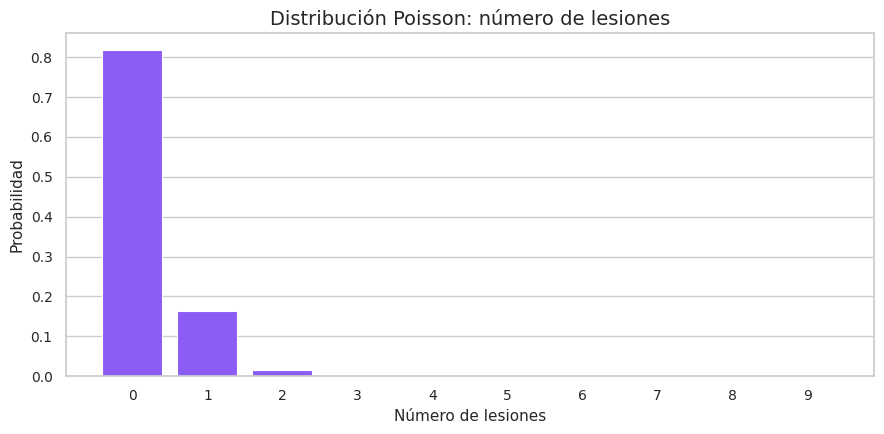

In [67]:
x = np.arange(0, 10)
poisson_probs = poisson.pmf(x, lambda_)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(x, poisson_probs, color=PALETTE[3], edgecolor="white", linewidth=0.8)
ax.set_title("Distribución Poisson: número de lesiones")
ax.set_xlabel("Número de lesiones")
ax.set_ylabel("Probabilidad")
ax.set_xticks(x)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

# Distribución continua (velocidad)

`POSTED_SPEED_LIMIT` es una variable discreta. La distribución normal se muestra únicamente como referencia visual, no como una afirmación de que los límites de velocidad sigan una normal.

In [68]:
mean_speed = df_p4["POSTED_SPEED_LIMIT"].mean()
std_speed = df_p4["POSTED_SPEED_LIMIT"].std()

print("Media:", mean_speed)
print("Desviación estándar:", std_speed)

Media: 28.4204717190799
Desviación estándar: 6.0174384999861275


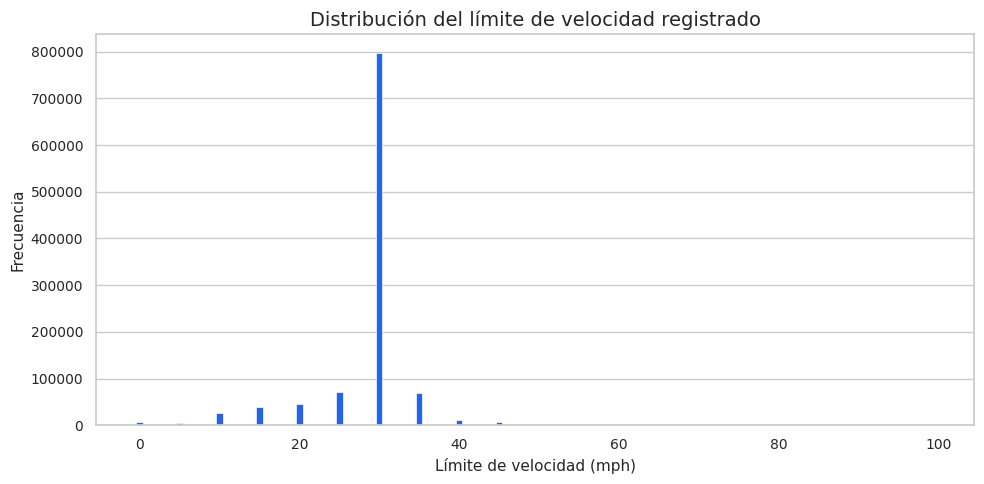

In [69]:
speed_counts = df_p4["POSTED_SPEED_LIMIT"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(speed_counts.index, speed_counts.values, color=PALETTE[0], edgecolor="white", linewidth=0.5)
ax.set_title("Distribución del límite de velocidad registrado")
ax.set_xlabel("Límite de velocidad (mph)")
ax.set_ylabel("Frecuencia")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Distribución Binomial

Se modela la variable **presencia de lesión** como un evento binario (éxito = al menos un lesionado en el accidente) y se analiza si puede representarse mediante una distribución Binomial.


Probabilidad de éxito estimada (p): 0.1444
Parámetros del modelo: n = 10, p = 0.1444


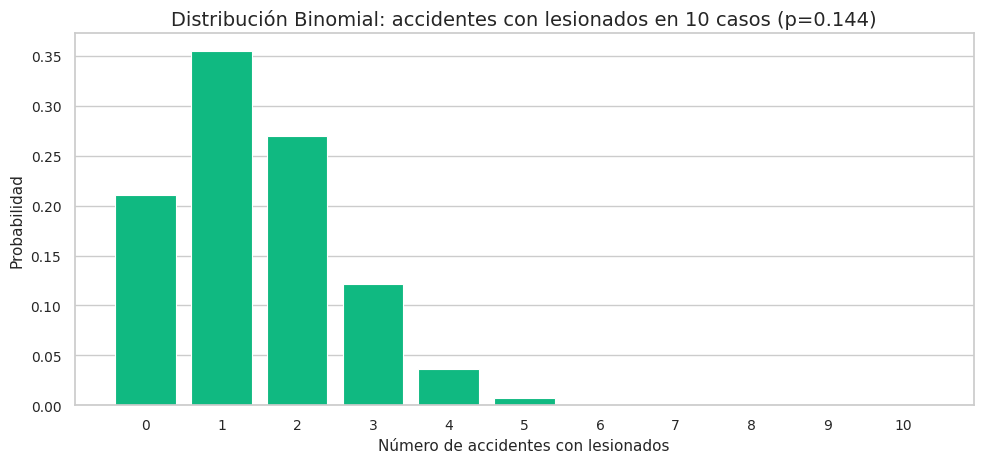


Probabilidades teóricas:
  P(X = 0) = 0.2102
  P(X = 1) = 0.3548
  P(X = 2) = 0.2695
  P(X = 3) = 0.1213
  P(X = 4) = 0.0358


In [70]:
# Estimación del parámetro p a partir de los datos
p_injury = df_p4["injury"].mean()
n_trials = 10

print(f"Probabilidad de éxito estimada (p): {p_injury:.4f}")
print(f"Parámetros del modelo: n = {n_trials}, p = {p_injury:.4f}")

k_values = np.arange(0, n_trials + 1)
binom_probs = binom.pmf(k_values, n_trials, p_injury)

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.bar(k_values, binom_probs, color=PALETTE[2], edgecolor="white", linewidth=0.8)
ax.set_title(f"Distribución Binomial: accidentes con lesionados en {n_trials} casos (p={p_injury:.3f})")
ax.set_xlabel("Número de accidentes con lesionados")
ax.set_ylabel("Probabilidad")
ax.set_xticks(k_values)
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

print("\nProbabilidades teóricas:")
for k in range(5):
    print(f"  P(X = {k}) = {binom_probs[k]:.4f}")

### Interpretación

Si se seleccionan 10 accidentes independientes con una probabilidad constante de lesión `p = 0.1441`, la distribución binomial es un modelo teórico para el número de accidentes con lesionados. En ese escenario, `P(X=0) = 0.2109` y `P(X=1) = 0.3551`.

El cálculo es didáctico: la independencia, la probabilidad constante y la representatividad de los 10 accidentes son supuestos que deben declararse. La distribución no demuestra por sí sola que el proceso real siga una binomial.

## Análisis inferencial

A partir de los resultados probabilísticos obtenidos, se responden las preguntas planteadas en las instrucciones del proyecto.


In [71]:
# Tabla comparativa de factores de riesgo
summary_data = {
    'Factor': ['Velocidad alta (>40 mph)', 'Condiciones nocturnas', 'Lluvia'],
    'Evento analizado': ['Fatalidad', 'Lesión grave', 'Lesión'],
    'P(evento | factor presente)': [
        df_p4[df_p4['high_speed']]['fatal'].mean(),
        df_p4[df_p4['is_night']]['severe'].mean(),
        df_p4[df_p4['is_rain']]['injury'].mean()
    ],
    'P(evento | factor ausente)': [
        df_p4[~df_p4['high_speed']]['fatal'].mean(),
        df_p4[~df_p4['is_night']]['severe'].mean(),
        df_p4[~df_p4['is_rain']]['injury'].mean()
    ]
}
df_risk = pd.DataFrame(summary_data)
df_risk['Aumento relativo'] = (
    df_risk['P(evento | factor presente)'] / df_risk['P(evento | factor ausente)']
).map(lambda x: f'{x:.2f}x')
print(df_risk.to_string(index=False))


                  Factor Evento analizado  P(evento | factor presente)  P(evento | factor ausente) Aumento relativo
Velocidad alta (>40 mph)        Fatalidad                       0.0034                      0.0010            3.31x
   Condiciones nocturnas     Lesión grave                       0.0222                      0.0140            1.59x
                  Lluvia           Lesión                       0.1768                      0.1415            1.25x


### Conclusiones del análisis inferencial

Las probabilidades observadas son mayores en los subgrupos definidos:

- Alta velocidad (>40 mph): fatalidad **0.34%** frente a **0.10%** en el grupo restante (**3.31x**).
- Condiciones nocturnas: lesión incapacitante **2.22%** frente a **1.40%** de día (**1.59x**).
- Lluvia: al menos un lesionado **17.74%** frente a **14.18%** sin lluvia (**1.25x**).

Estos cocientes sugieren asociaciones que podrían investigarse con pruebas de hipótesis o modelos de regresión. No deben presentarse como efectos causales, ya que no se han controlado otras variables ni calculado intervalos de confianza.

# Extensión analítica del proyecto

El análisis presentado en las secciones anteriores corresponde al proyecto estadístico original. En él se realizó una exploración descriptiva de los accidentes de tránsito de Chicago, utilizando tablas de frecuencia, medidas estadísticas, probabilidades y distribuciones básicas.

A partir de esa primera versión, se incorpora una extensión analítica orientada a fortalecer el proyecto con prácticas de análisis de datos: validación de calidad, transformación de variables, comparación de grupos y comunicación de resultados con mayor rigor estadístico.

## Recorrido de las fases de ampliación

- **Fase 1 — Calidad y análisis comparativo:** auditoría de la fuente, cobertura temporal, variables derivadas, concentración por día y hora, riesgo relativo y odds ratio.
- **Fase 2 — Inferencia estadística:** intervalos de confianza, pruebas chi-cuadrado, tamaño de efecto y evaluación de la significancia de las asociaciones observadas.
- **Fase 3 — Modelos estadísticos:** regresión logística para estimar la probabilidad modelada de lesiones, accidentes graves y fatalidades, además de una evaluación más rigurosa del desempeño predictivo.
- **Fase 4 — Análisis temporal y geográfico:** evolución de los accidentes a lo largo del tiempo, mapas de concentración, calles y zonas con mayor frecuencia o severidad.

La Fase 1 comienza con una base confiable: antes de aplicar pruebas o modelos, es necesario conocer la calidad de los datos y definir correctamente los eventos que se van a comparar. Las métricas incluidas en esta ampliación describen asociaciones dentro de los accidentes registrados; no representan tasas de riesgo poblacional ni demuestran causalidad.

## Contrato de calidad de la extracción Gold

La validación detallada de duplicados, rangos, coordenadas y esquema se
ejecuta en BigQuery mediante dbt. Aquí solo comprobamos que el notebook
recibió el grano esperado y que las columnas críticas siguen disponibles
antes de comenzar las fases estadísticas.


In [72]:
df_quality = df.copy()

quality_report = pd.DataFrame({
    "Métrica": [
        "Registros recibidos",
        "IDs duplicados",
        "Fechas nulas",
        "Horas fuera de 0–23",
        "Días fuera de 1–7",
        "Meses fuera de 1–12",
        "Clima nulo",
        "Iluminación nula",
        "Coordenadas disponibles",
    ],
    "Valor": [
        len(df_quality),
        int(df_quality["CRASH_RECORD_ID"].duplicated().sum()),
        int(df_quality["CRASH_DATE"].isna().sum()),
        int((~df_quality["CRASH_HOUR"].between(0, 23)).sum()),
        int((~df_quality["CRASH_DAY_OF_WEEK"].between(1, 7)).sum()),
        int((~df_quality["CRASH_MONTH"].between(1, 12)).sum()),
        int(df_quality["WEATHER_CONDITION"].isna().sum()),
        int(df_quality["LIGHTING_CONDITION"].isna().sum()),
        int((df_quality["LATITUDE"].notna() & df_quality["LONGITUDE"].notna()).sum()),
    ],
})

coverage = pd.DataFrame({
    "Métrica": ["Fecha mínima", "Fecha máxima", "Años cubiertos"],
    "Valor": [
        df_quality["CRASH_DATE"].min().date(),
        df_quality["CRASH_DATE"].max().date(),
        df_quality["CRASH_DATE"].dt.year.nunique(),
    ],
})

quality_report


,Métrica,Valor
0,Registros recibidos,1079880
1,IDs duplicados,0
2,Fechas nulas,0
3,Horas fuera de 0–23,0
4,Días fuera de 1–7,0
5,Meses fuera de 1–12,0
6,Clima nulo,0
7,Iluminación nula,0
8,Coordenadas disponibles,1071405


In [73]:
coverage

,Métrica,Valor
0,Fecha mínima,2013-03-03
1,Fecha máxima,2026-07-31
2,Años cubiertos,14


### Interpretación de calidad

La tabla permite verificar si el análisis trabaja con una base consistente. Los registros anómalos no se eliminan automáticamente: primero se identifican y después se decide, según la variable, si corresponde excluirlos o tratarlos como una categoría informativa.

## 2. Variables derivadas para el análisis

Se reutilizan los tipos y campos derivados recibidos desde Gold y se
crean únicamente indicadores específicos de esta investigación, como
hora pico, clima adverso, límites altos y lesiones por unidad.


In [74]:
analysis = df.copy()

analysis["CRASH_DATE"] = pd.to_datetime(analysis["CRASH_DATE"], errors="coerce")
analysis["year"] = analysis["CRASH_DATE"].dt.year
analysis["is_weekend"] = analysis["CRASH_DAY_OF_WEEK"].isin([1, 7])
analysis["is_rush_hour"] = analysis["CRASH_HOUR"].isin([7, 8, 9, 16, 17, 18])
analysis["is_intersection"] = analysis["INTERSECTION_RELATED_I"].fillna(False).astype(bool)
analysis["is_hit_and_run"] = analysis["HIT_AND_RUN_I"].fillna(False).astype(bool)
analysis["is_dark"] = analysis["LIGHTING_CONDITION"].isin([
    "DARKNESS",
    "DARKNESS, LIGHTED ROAD",
])
analysis["is_bad_weather"] = analysis["WEATHER_CONDITION"].isin([
    "RAIN",
    "SNOW",
    "FREEZING RAIN/DRIZZLE",
    "SLEET/HAIL",
    "BLOWING SNOW",
])
analysis["high_speed"] = analysis["POSTED_SPEED_LIMIT"] > 40
analysis["has_injury"] = analysis["INJURIES_TOTAL"] > 0
analysis["is_fatal"] = analysis["INJURIES_FATAL"] > 0
analysis["is_severe"] = analysis["MOST_SEVERE_INJURY"].isin([
    "INCAPACITATING INJURY",
    "FATAL",
])
analysis["injuries_per_unit"] = np.where(
    analysis["NUM_UNITS"] > 0,
    analysis["INJURIES_TOTAL"] / analysis["NUM_UNITS"],
    np.nan,
)

feature_summary = pd.DataFrame({
    "Indicador": [
        "Fin de semana", "Hora pico", "Intersección", "Hit-and-run",
        "Oscuridad", "Clima adverso", "Límite alto", "Con lesión",
        "Fatal", "Grave",
    ],
    "Registros": [
        int(analysis[c].sum()) for c in [
            "is_weekend", "is_rush_hour", "is_intersection", "is_hit_and_run",
            "is_dark", "is_bad_weather", "high_speed", "has_injury",
            "is_fatal", "is_severe",
        ]
    ],
})

feature_summary


,Indicador,Registros
0,Fin de semana,293556
1,Hora pico,382369
2,Intersección,235938
3,Hit-and-run,324484
4,Oscuridad,284289
5,Clima adverso,128756
6,Límite alto,8513
7,Con lesión,155943
8,Fatal,1130
9,Grave,18554


## 3. Concentración temporal: día y hora

El heatmap permite observar conjuntamente la hora y el día de la semana.

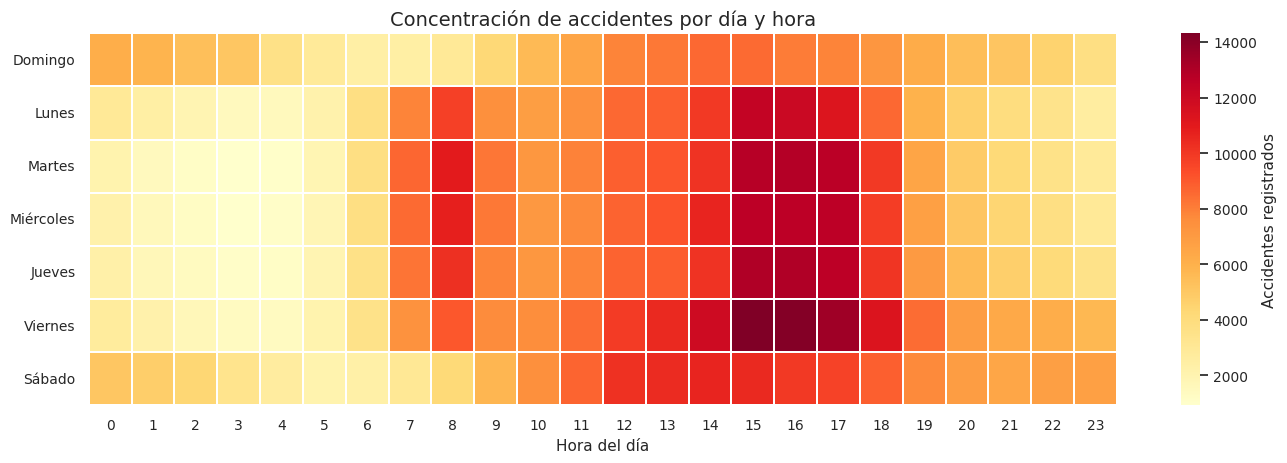

In [75]:
day_names = {1: "Domingo", 2: "Lunes", 3: "Martes", 4: "Miércoles", 5: "Jueves", 6: "Viernes", 7: "Sábado"}
heatmap_data = pd.crosstab(analysis["CRASH_DAY_OF_WEEK"].map(day_names), analysis["CRASH_HOUR"]).reindex(list(day_names.values()))
fig, ax = plt.subplots(figsize=(14, 4.8))
sns.heatmap(heatmap_data, cmap="YlOrRd", linewidths=0.2, linecolor="white", cbar_kws={"label": "Accidentes registrados"}, ax=ax)
ax.set_title("Concentración de accidentes por día y hora")
ax.set_xlabel("Hora del día")
ax.set_ylabel("")
fig.tight_layout()
plt.show()

## 4. Riesgo relativo y odds ratio

- **Riesgo observado:** proporción de accidentes con el evento dentro de cada grupo.
- **Diferencia absoluta:** riesgo con el factor menos riesgo sin el factor.
- **Riesgo relativo (RR):** cuánto se multiplica el riesgo observado.
- **Odds ratio (OR):** comparación de las odds del evento entre ambos grupos.

Estas métricas son asociaciones descriptivas y no controlan por variables de confusión.

In [76]:
def compare_binary_event(data, factor, outcome, factor_label, outcome_label):
    present = data[data[factor].fillna(False)]
    absent = data[~data[factor].fillna(False)]
    a = int(present[outcome].sum())
    b = int(len(present) - a)
    c = int(absent[outcome].sum())
    d = int(len(absent) - c)
    risk_present = a / len(present) if len(present) else np.nan
    risk_absent = c / len(absent) if len(absent) else np.nan
    return {"Factor": factor_label, "Evento": outcome_label, "n factor presente": len(present), "n factor ausente": len(absent), "Riesgo con factor": risk_present, "Riesgo sin factor": risk_absent, "Diferencia absoluta": risk_present - risk_absent, "Riesgo relativo": risk_present / risk_absent if risk_absent else np.nan, "Odds ratio": (a * d) / (b * c) if b > 0 and c > 0 else np.nan}
comparisons = pd.DataFrame([
    compare_binary_event(analysis, "is_bad_weather", "has_injury", "Clima adverso", "Al menos un lesionado"),
    compare_binary_event(analysis, "is_dark", "is_severe", "Oscuridad", "Lesión grave o fatal"),
    compare_binary_event(analysis, "high_speed", "is_fatal", "Límite > 40 mph", "Fatalidad"),
    compare_binary_event(analysis, "is_weekend", "has_injury", "Fin de semana", "Al menos un lesionado"),
])
comparisons.style.format({"Riesgo con factor": "{:.2%}", "Riesgo sin factor": "{:.2%}", "Diferencia absoluta": "{:.2%}", "Riesgo relativo": "{:.2f}x", "Odds ratio": "{:.2f}x"})

,Factor,Evento,n factor presente,n factor ausente,Riesgo con factor,Riesgo sin factor,Diferencia absoluta,Riesgo relativo,Odds ratio
0,Clima adverso,Al menos un lesionado,128756,951124,16.22%,14.20%,2.02%,1.14x,1.17x
1,Oscuridad,Lesión grave o fatal,284289,795591,2.45%,1.46%,0.99%,1.68x,1.70x
2,Límite > 40 mph,Fatalidad,8513,1071367,0.34%,0.10%,0.24%,3.31x,3.32x
3,Fin de semana,Al menos un lesionado,293556,786324,14.98%,14.24%,0.74%,1.05x,1.06x


### Interpretación de las comparaciones

El riesgo relativo y el odds ratio deben leerse junto con el tamaño de cada grupo y la diferencia absoluta. Un cociente elevado puede corresponder a un evento poco frecuente; por eso no debe utilizarse como única medida de importancia.

Los resultados indican qué relaciones merece la pena estudiar con pruebas de independencia, intervalos de confianza y regresión logística.

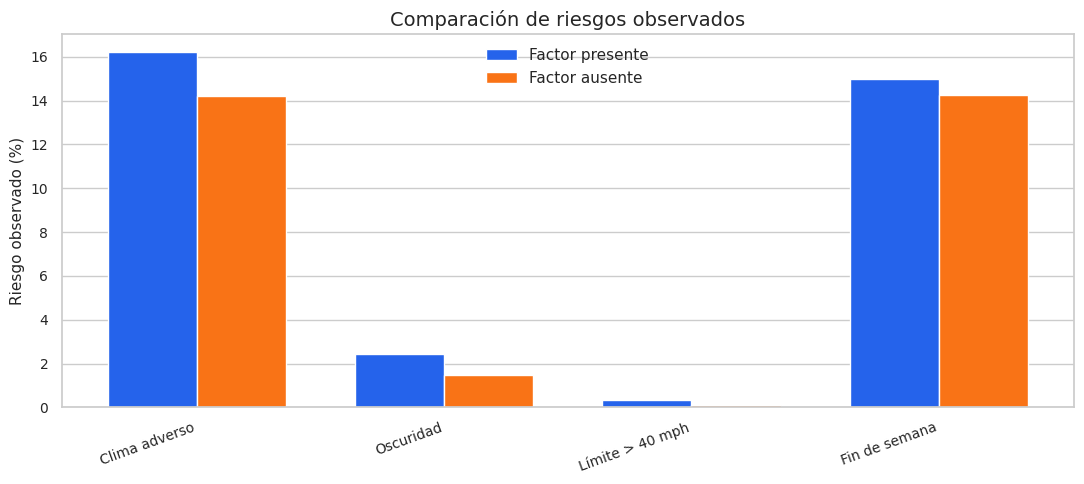

In [77]:
risk_plot = comparisons.copy()
risk_plot["Riesgo con factor (%)"] = risk_plot["Riesgo con factor"] * 100
risk_plot["Riesgo sin factor (%)"] = risk_plot["Riesgo sin factor"] * 100
x = np.arange(len(risk_plot))
width = 0.36
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, risk_plot["Riesgo con factor (%)"], width, label="Factor presente", color=PALETTE[0])
ax.bar(x + width / 2, risk_plot["Riesgo sin factor (%)"], width, label="Factor ausente", color=PALETTE[1])
ax.set_title("Comparación de riesgos observados")
ax.set_ylabel("Riesgo observado (%)")
ax.set_xticks(x)
ax.set_xticklabels(risk_plot["Factor"], rotation=20, ha="right")
ax.legend()
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()

## Lectura ejecutiva de la Fase 1

Esta fase documenta la calidad de la fuente, transforma las columnas en eventos analíticos reutilizables y compara grupos con métricas de asociación más informativas que un porcentaje aislado.

La siguiente mejora estadística recomendada es añadir intervalos de confianza, pruebas chi-cuadrado y modelos logísticos que controlen simultáneamente por varias variables.

# Fase 2 — Inferencia estadística

En la Fase 1 se identificaron diferencias entre grupos mediante porcentajes, riesgo relativo y odds ratio. En esta fase se evalúa si esas diferencias son suficientemente claras para considerarlas asociaciones estadísticas dentro de la muestra.

Se utilizarán pruebas chi-cuadrado, el tamaño de efecto de Cramér y intervalos de confianza del 95%. La prueba chi-cuadrado ayuda a evaluar si dos variables categóricas parecen estar relacionadas; Cramér indica qué tan grande es esa relación; y el intervalo de confianza muestra un rango razonable para cada proporción observada.

> Con más de un millón de registros, una diferencia muy pequeña puede resultar estadísticamente significativa. Por eso se interpretan juntos el valor p, el tamaño de efecto y la diferencia práctica.

## 1. Pruebas chi-cuadrado de independencia

Se evalúan cuatro relaciones definidas en la fase anterior: clima adverso con lesiones, oscuridad con severidad, límite de velocidad alto con fatalidad y fin de semana con lesiones.

In [78]:
def chi_square_association(data, factor, outcome, factor_label, outcome_label):
    table = pd.crosstab(data[factor], data[outcome]).reindex(
        index=[False, True], columns=[False, True], fill_value=0
    )
    chi2, p_value, degrees_freedom, expected = chi2_contingency(table)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / n) if n else np.nan
    return {
        "Factor": factor_label,
        "Evento": outcome_label,
        "Chi-cuadrado": chi2,
        "Valor p": p_value,
        "Grados de libertad": degrees_freedom,
        "V de Cramér": cramers_v,
        "Significativo (α=0.05)": p_value < 0.05,
    }

chi_square_results = pd.DataFrame([
    chi_square_association(analysis, "is_bad_weather", "has_injury", "Clima adverso", "Al menos un lesionado"),
    chi_square_association(analysis, "is_dark", "is_severe", "Oscuridad", "Lesión grave o fatal"),
    chi_square_association(analysis, "high_speed", "is_fatal", "Límite > 40 mph", "Fatalidad"),
    chi_square_association(analysis, "is_weekend", "has_injury", "Fin de semana", "Al menos un lesionado"),
])

chi_square_results.style.format({
    "Chi-cuadrado": "{:,.2f}",
    "Valor p": "{:.4g}",
    "V de Cramér": "{:.4f}",
})

,Factor,Evento,Chi-cuadrado,Valor p,Grados de libertad,V de Cramér,Significativo (α=0.05)
0,Clima adverso,Al menos un lesionado,372.68,4.876e-83,1,0.0186,True
1,Oscuridad,Lesión grave o fatal,"1,213.84",6e-266,1,0.0335,True
2,Límite > 40 mph,Fatalidad,43.48,4.29e-11,1,0.0063,True
3,Fin de semana,Al menos un lesionado,94.37,2.612e-22,1,0.0093,True


### Interpretación de la prueba chi-cuadrado

La columna **Significativo** indica si existe evidencia estadística de una relación entre el factor y el evento. Sin embargo, “significativo” no significa “importante” ni “causal”.

El **V de Cramér** ayuda a poner la diferencia en contexto: valores cercanos a cero representan asociaciones débiles, aunque el valor p sea pequeño. En este dataset tan grande, el tamaño del efecto es más útil para saber si la diferencia tiene relevancia práctica.

## 2. Intervalos de confianza para las proporciones

Se calculan intervalos de confianza del 95% para el riesgo observado con el factor presente y ausente. Se utiliza el intervalo de Wilson, apropiado para proporciones y especialmente útil cuando el evento es poco frecuente.

In [79]:
def wilson_interval(successes, total, confidence=0.95):
    if total == 0:
        return np.nan, np.nan
    z = norm.ppf(1 - (1 - confidence) / 2)
    proportion = successes / total
    denominator = 1 + z**2 / total
    center = (proportion + z**2 / (2 * total)) / denominator
    margin = z * np.sqrt((proportion * (1 - proportion) / total) + z**2 / (4 * total**2)) / denominator
    return center - margin, center + margin

def confidence_table(data, factor, outcome, factor_label, outcome_label):
    rows = []
    for present, group_label in [(False, "Factor ausente"), (True, "Factor presente")]:
        group = data[data[factor].fillna(False) == present]
        successes = int(group[outcome].sum())
        lower, upper = wilson_interval(successes, len(group))
        rows.append({
            "Factor": factor_label,
            "Evento": outcome_label,
            "Grupo": group_label,
            "n": len(group),
            "Casos": successes,
            "Proporción": successes / len(group) if len(group) else np.nan,
            "IC 95% inferior": lower,
            "IC 95% superior": upper,
        })
    return rows

confidence_results = pd.DataFrame(sum([
    confidence_table(analysis, "is_bad_weather", "has_injury", "Clima adverso", "Al menos un lesionado"),
    confidence_table(analysis, "is_dark", "is_severe", "Oscuridad", "Lesión grave o fatal"),
    confidence_table(analysis, "high_speed", "is_fatal", "Límite > 40 mph", "Fatalidad"),
    confidence_table(analysis, "is_weekend", "has_injury", "Fin de semana", "Al menos un lesionado"),
], []))

confidence_results.style.format({
    "Proporción": "{:.2%}",
    "IC 95% inferior": "{:.2%}",
    "IC 95% superior": "{:.2%}",
})

,Factor,Evento,Grupo,n,Casos,Proporción,IC 95% inferior,IC 95% superior
0,Clima adverso,Al menos un lesionado,Factor ausente,951124,135064,14.20%,14.13%,14.27%
1,Clima adverso,Al menos un lesionado,Factor presente,128756,20879,16.22%,16.02%,16.42%
2,Oscuridad,Lesión grave o fatal,Factor ausente,795591,11597,1.46%,1.43%,1.48%
3,Oscuridad,Lesión grave o fatal,Factor presente,284289,6957,2.45%,2.39%,2.50%
4,Límite > 40 mph,Fatalidad,Factor ausente,1071367,1101,0.10%,0.10%,0.11%
5,Límite > 40 mph,Fatalidad,Factor presente,8513,29,0.34%,0.24%,0.49%
6,Fin de semana,Al menos un lesionado,Factor ausente,786324,111972,14.24%,14.16%,14.32%
7,Fin de semana,Al menos un lesionado,Factor presente,293556,43971,14.98%,14.85%,15.11%


### Interpretación de los intervalos de confianza

Cada intervalo muestra un rango plausible para la proporción real dentro de un proceso similar al de los accidentes registrados. Si los intervalos de dos grupos están muy separados, la diferencia es más clara; si se solapan mucho, conviene ser más prudente.

Estos intervalos reflejan incertidumbre de muestreo, pero no corrigen posibles sesgos del dataset ni convierten el análisis en una estimación de riesgo para toda la ciudad.

## 3. Comparación visual con incertidumbre

El siguiente gráfico muestra los riesgos observados junto con sus intervalos de confianza del 95%. Las barras permiten comparar el tamaño de los eventos y las líneas verticales muestran la incertidumbre de cada estimación.

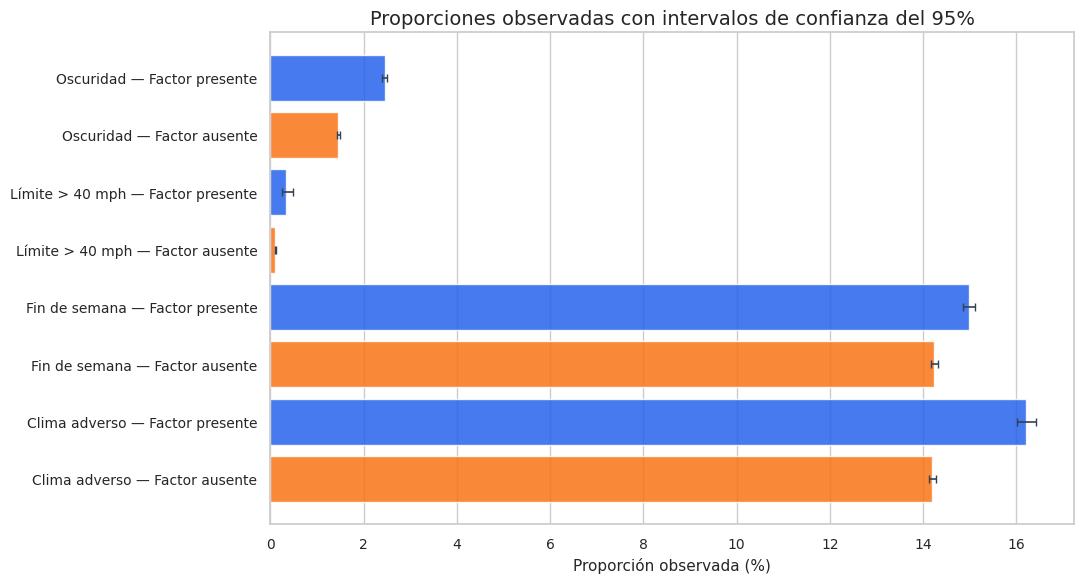

In [80]:
plot_data = confidence_results.copy()
plot_data["Etiqueta"] = plot_data["Factor"] + " — " + plot_data["Grupo"]
plot_data = plot_data.sort_values(["Factor", "Grupo"])

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(plot_data))
values = plot_data["Proporción"].to_numpy() * 100
lower = (plot_data["Proporción"] - plot_data["IC 95% inferior"]).to_numpy() * 100
upper = (plot_data["IC 95% superior"] - plot_data["Proporción"]).to_numpy() * 100
colors = [PALETTE[0] if group == "Factor presente" else PALETTE[1] for group in plot_data["Grupo"]]

ax.barh(y, values, color=colors, alpha=0.85)
ax.errorbar(values, y, xerr=[lower, upper], fmt="none", ecolor="#334155", capsize=3, linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels(plot_data["Etiqueta"])
ax.set_xlabel("Proporción observada (%)")
ax.set_title("Proporciones observadas con intervalos de confianza del 95%")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

### Interpretación del gráfico inferencial

Las barras muestran que los eventos son más frecuentes en algunos grupos, pero las líneas de error recuerdan que cada porcentaje es una estimación. La comparación debe considerar simultáneamente la diferencia entre barras, la amplitud de los intervalos y el tamaño del efecto.

Este gráfico permite comunicar los resultados con más transparencia que un porcentaje aislado.

## Lectura ejecutiva de la Fase 2

La Fase 2 añade evidencia estadística a las comparaciones de la Fase 1. Ahora el notebook distingue entre una diferencia que puede detectarse estadísticamente y una diferencia que además tiene un tamaño relevante para la interpretación práctica.

La Fase 3, que se desarrolla a continuación, incorpora modelos logísticos multivariables para estudiar varios factores al mismo tiempo y evaluar qué tan bien separan los accidentes con consecuencias de los accidentes sin ellas.

# Fase 3 — Modelos logísticos multivariables

La Fase 2 permitió detectar asociaciones entre factores y consecuencias mediante comparaciones bivariadas: cada relación se estudiaba entre un factor y un resultado. Esa aproximación es útil para describir la muestra, pero no permite analizar simultáneamente varias características del accidente. Por ejemplo, una diferencia observada entre accidentes con oscuridad y sin oscuridad puede estar relacionada también con la hora, el tipo de vía, el límite de velocidad o el número de unidades involucradas.

En esta fase se utiliza regresión logística binaria. Este modelo es apropiado cuando el resultado que queremos estudiar tiene dos estados: ocurre o no ocurre. Se ajusta un modelo independiente para tres eventos:

- **Al menos un lesionado** (`has_injury`).
- **Lesión grave o fatal** (`is_severe`).
- **Al menos una fatalidad** (`is_fatal`).

### ¿Qué calcula una regresión logística?

Para cada accidente, el modelo combina los predictores disponibles y calcula un valor lineal:

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k
$$

Ese valor se transforma mediante la función logística para obtener una puntuación entre 0 y 1:

$$
p = \frac{1}{1 + e^{-z}}
$$

En un modelo sin balanceo, `p` se interpretaría directamente como la probabilidad estimada del evento bajo las condiciones observadas. En este notebook se utiliza `class_weight="balanced"` para que los eventos poco frecuentes, especialmente las fatalidades, tengan suficiente peso durante el entrenamiento. Por eso las salidas deben leerse como **probabilidades o puntuaciones modeladas para clasificación**, no como probabilidades perfectamente calibradas de riesgo individual.

El modelo no demuestra que un factor cause un accidente. Su utilidad aquí es medir asociaciones ajustadas, comparar la capacidad de discriminación de los resultados y documentar un flujo reproducible de modelado estadístico sobre datos del warehouse.

## 1. Diseño del modelado

### Unidad de observación y variables objetivo

La unidad de observación sigue siendo un accidente: cada fila representa un registro de `fct_traffic_crashes` y sus dimensiones relacionadas. Las variables objetivo se construyen a partir de las medidas y categorías de severidad recibidas desde Gold:

- `has_injury = 1` si `INJURIES_TOTAL > 0`.
- `is_severe = 1` si la máxima severidad es una lesión incapacitante o fatal.
- `is_fatal = 1` si `INJURIES_FATAL > 0`.

En esta ejecución se modelan 1,079,880 registros. La prevalencia aproximada de los eventos es 14.44% para al menos un lesionado, 1.72% para lesión grave o fatal y 0.10% para fatalidad. Esta diferencia es importante: no se puede evaluar un modelo de fatalidad con los mismos criterios que un modelo de lesiones relativamente más frecuentes.

### Predictores y control de fuga de información

Los predictores describen el contexto disponible del accidente: límite de velocidad, número de unidades, fin de semana, oscuridad, clima adverso, intersección, hit-and-run, hora, mes, tipo de vía y dispositivo de control de tráfico.

No se incluyen `INJURIES_TOTAL`, `INJURIES_FATAL` ni `MOST_SEVERE_INJURY` como predictores. Esas columnas contienen directamente la consecuencia que intentamos explicar; incorporarlas produciría **fuga de información** y un resultado artificialmente optimista. El modelo debe aprender a partir del contexto del accidente, no a partir de la respuesta.

### Preparación y división de los datos

Las variables numéricas se imputan con la mediana cuando es necesario. Las variables categóricas se convierten mediante one-hot encoding: una categoría se mantiene como referencia y las demás se representan mediante indicadores 0/1. Las categorías con menos del 0.5% de los registros se agrupan como infrecuentes para evitar que un grupo diminuto genere coeficientes inestables.

Después, los datos se separan en 80% para entrenamiento y 20% para prueba. La división es estratificada, por lo que la proporción de positivos se conserva aproximadamente en ambos conjuntos. El conjunto de prueba no participa en el ajuste y permite comprobar cómo se comporta el modelo ante registros que no vio durante el entrenamiento.

Finalmente, `class_weight="balanced"` aumenta el peso relativo de la clase positiva. Esto es útil para no obtener un modelo que prediga siempre “sin fatalidad” solo porque esa es la clase mayoritaria, pero también puede aumentar los falsos positivos y modificar la calibración de las probabilidades.

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.base import clone


phase3_numeric_features = [
    "POSTED_SPEED_LIMIT",
    "NUM_UNITS",
]
phase3_binary_features = [
    "is_weekend",
    "is_dark",
    "is_bad_weather",
    "is_intersection",
    "is_hit_and_run",
]
phase3_categorical_features = [
    "CRASH_HOUR",
    "CRASH_MONTH",
    "TRAFFICWAY_TYPE",
    "TRAFFIC_CONTROL_DEVICE",
]
phase3_features = (
    phase3_numeric_features
    + phase3_binary_features
    + phase3_categorical_features
)
phase3_outcomes = {
    "has_injury": "Al menos un lesionado",
    "is_severe": "Lesión grave o fatal",
    "is_fatal": "Al menos una fatalidad",
}

phase3_frame = analysis[phase3_features + list(phase3_outcomes)].copy()
phase3_frame = phase3_frame.dropna(subset=list(phase3_outcomes))

for column in phase3_numeric_features:
    phase3_frame[column] = pd.to_numeric(
        phase3_frame[column], errors="coerce"
    )
for column in phase3_binary_features:
    phase3_frame[column] = phase3_frame[column].fillna(False).astype(int)
for column in phase3_categorical_features:
    phase3_frame[column] = (
        phase3_frame[column].astype("string").fillna("UNKNOWN")
    )
for column in phase3_outcomes:
    phase3_frame[column] = phase3_frame[column].astype(int)

phase3_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            phase3_numeric_features,
        ),
        (
            "binary",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
            ]),
            phase3_binary_features,
        ),
        (
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="infrequent_if_exist",
                        min_frequency=0.005,
                        drop="first",
                        sparse_output=True,
                    ),
                ),
            ]),
            phase3_categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

phase3_models = {}
phase3_splits = {}
phase3_metrics_rows = []

for outcome, outcome_label in phase3_outcomes.items():
    X = phase3_frame[phase3_features]
    y = phase3_frame[outcome]
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y,
    )

    model = Pipeline([
        ("preprocessor", clone(phase3_preprocessor)),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=300,
                random_state=42,
                solver="liblinear",
            ),
        ),
    ])
    model.fit(X_train, y_train)
    test_probability = model.predict_proba(X_test)[:, 1]
    test_prediction = (test_probability >= 0.50).astype(int)

    phase3_models[outcome] = model
    phase3_splits[outcome] = {
        "y_test": y_test,
        "probability": test_probability,
        "prediction": test_prediction,
        "prevalence": y_test.mean(),
    }
    phase3_metrics_rows.append({
        "Resultado": outcome_label,
        "Casos positivos": int(y.sum()),
        "Prevalencia": y.mean(),
        "Accuracy": accuracy_score(y_test, test_prediction),
        "Balanced accuracy": balanced_accuracy_score(y_test, test_prediction),
        "Precision": precision_score(y_test, test_prediction, zero_division=0),
        "Recall": recall_score(y_test, test_prediction, zero_division=0),
        "F1": f1_score(y_test, test_prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, test_probability),
        "PR-AUC": average_precision_score(y_test, test_probability),
    })

phase3_metrics = pd.DataFrame(phase3_metrics_rows).set_index("Resultado")

print(f"Registros utilizados: {len(phase3_frame):,}")
print("División: 80% entrenamiento / 20% prueba | semilla: 42")
phase3_metrics.style.format({
    "Prevalencia": "{:.2%}",
    "Accuracy": "{:.2%}",
    "Balanced accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1": "{:.2%}",
    "ROC-AUC": "{:.3f}",
    "PR-AUC": "{:.3f}",
})

Registros utilizados: 1,079,880
División: 80% entrenamiento / 20% prueba | semilla: 42


,Casos positivos,Prevalencia,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Resultado,,,,,,,,,
Al menos un lesionado,155943,14.44%,66.75%,63.71%,23.86%,59.43%,34.05%,0.689,0.276
Lesión grave o fatal,18554,1.72%,65.81%,64.34%,3.12%,62.81%,5.94%,0.691,0.037
Al menos una fatalidad,1130,0.10%,72.86%,68.51%,0.25%,64.16%,0.49%,0.742,0.005


### Interpretación de las métricas

La tabla resume el comportamiento de cada modelo sobre el conjunto de prueba. La columna **Casos positivos** muestra cuántos registros pertenecen al evento que se intenta detectar y **Prevalencia** muestra qué proporción representan sobre todos los registros. Estas dos columnas son esenciales para interpretar el resto: una precision de 3% puede ser baja en términos absolutos, pero no tiene el mismo significado cuando el evento aparece en 1.72% de los accidentes que cuando aparece en 14.44%.

Las métricas de clasificación se interpretan así:

- **Accuracy:** proporción total de predicciones correctas. Puede ser engañosa cuando hay un fuerte desbalanceo porque muchos negativos pueden ocultar un mal reconocimiento de los positivos.
- **Balanced accuracy:** promedio del recall de la clase negativa y de la clase positiva. Da el mismo peso a ambas clases y por eso es más informativa en este caso.
- **Precision:** de todos los accidentes que el modelo marcó como positivos, cuántos realmente lo eran. Un valor bajo indica muchos falsos positivos.
- **Recall:** de todos los accidentes que realmente tenían el resultado, qué proporción fue detectada. Un recall alto implica menos falsos negativos.
- **F1:** media armónica entre precision y recall. Solo es alta cuando ambas son razonablemente altas.
- **ROC-AUC:** capacidad de ordenar los casos positivos por encima de los negativos a través de distintos umbrales. Un valor de 0.50 equivale aproximadamente a ordenar al azar; cuanto más se acerca a 1, mejor es la discriminación.
- **PR-AUC:** resume el equilibrio entre precision y recall. Es especialmente importante para lesiones graves y fatalidades, porque son eventos poco frecuentes y la curva ROC puede parecer favorable aunque la precision sea baja.

### Qué dicen los resultados de esta ejecución

Los modelos alcanzan ROC-AUC de aproximadamente 0.689 para lesiones, 0.693 para lesiones graves o fatales y 0.716 para fatalidades. Esto indica una capacidad de discriminación **moderada**: el modelo encuentra patrones útiles y ordena los casos mejor que el azar, pero no separa perfectamente ambos grupos. No sería correcto presentar estos valores como un sistema predictivo definitivo.

El PR-AUC es 0.275 para lesiones, 0.041 para lesiones graves o fatales y 0.003 para fatalidades. Al compararlos con sus prevalencias base —14.44%, 1.72% y 0.10%, respectivamente— se observa que el modelo mejora el ordenamiento respecto a seleccionar casos al azar, aunque la precision absoluta sigue siendo limitada para los eventos raros. En la fatalidad, por ejemplo, un pequeño porcentaje de predicciones positivas correctas puede coexistir con muchos falsos positivos porque el evento aparece en muy pocos registros.

El balanceo permite obtener recalls cercanos a 60% para los tres resultados, pero la precision disminuye de manera importante en los eventos raros. Esto representa un intercambio estadístico: detectar más casos positivos exige aceptar más falsas alarmas. La lectura correcta es que el modelo puede servir como herramienta exploratoria para priorizar casos o investigar factores, no como una decisión automática sin calibración, validación temporal y una definición explícita del costo de cada error.

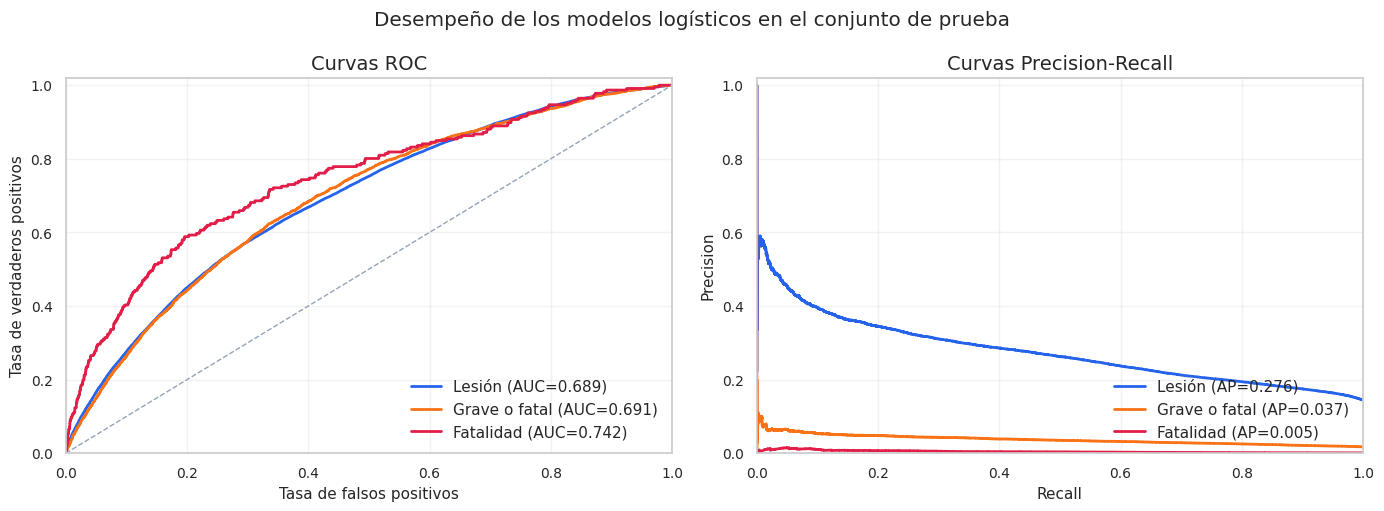

In [82]:
phase3_labels = {
    "has_injury": "Lesión",
    "is_severe": "Grave o fatal",
    "is_fatal": "Fatalidad",
}
phase3_colors = {
    "has_injury": PALETTE[0],
    "is_severe": PALETTE[1],
    "is_fatal": PALETTE[4],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

for outcome, label in phase3_labels.items():
    split = phase3_splits[outcome]
    fpr, tpr, _ = roc_curve(split["y_test"], split["probability"])
    roc_auc = roc_auc_score(split["y_test"], split["probability"])
    precision, recall, _ = precision_recall_curve(
        split["y_test"], split["probability"]
    )
    pr_auc = average_precision_score(
        split["y_test"], split["probability"]
    )
    color = phase3_colors[outcome]
    axes[0].plot(
        fpr,
        tpr,
        color=color,
        linewidth=2,
        label=f"{label} (AUC={roc_auc:.3f})",
    )
    axes[1].plot(
        recall,
        precision,
        color=color,
        linewidth=2,
        label=f"{label} (AP={pr_auc:.3f})",
    )

axes[0].plot([0, 1], [0, 1], color="#94A3B8", linestyle="--", linewidth=1)
axes[0].set_title("Curvas ROC")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)

axes[1].set_title("Curvas Precision-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.02)

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right")

fig.suptitle("Desempeño de los modelos logísticos en el conjunto de prueba")
fig.tight_layout()
plt.show()

### Interpretación de las curvas

El gráfico contiene dos evaluaciones complementarias del mismo conjunto de predicciones.

En la **curva ROC**, el eje horizontal representa la tasa de falsos positivos y el eje vertical la tasa de verdaderos positivos. Cada punto corresponde a un umbral diferente para convertir la puntuación del modelo en una clasificación. La línea diagonal representa un clasificador aleatorio. Las curvas de los tres modelos se sitúan por encima de esa referencia, lo que coincide con sus ROC-AUC superiores a 0.50: existe señal estadística en los predictores, aunque la separación es moderada.

La **curva Precision-Recall** muestra el intercambio entre encontrar más positivos y mantener la proporción de aciertos entre las predicciones positivas. La línea de base implícita depende de la prevalencia: es mucho más baja para fatalidad que para lesiones. Por esta razón, la curva PR es más exigente y más representativa para los resultados raros. Una curva puede tener un ROC-AUC razonable y, al mismo tiempo, una precision baja cuando se intenta detectar un evento que aparece en solo una fracción mínima de los accidentes.

Las curvas no fijan un único punto de decisión. El umbral de 0.50 se usa después para las matrices de confusión, pero un proyecto operativo podría elegir otro umbral según el objetivo: reducir falsos negativos, reducir falsas alarmas o equilibrar ambos costos. La selección de ese umbral debería hacerse usando datos de validación y una justificación de negocio o de seguridad vial.

In [83]:
phase3_coefficient_rows = []

for outcome, model in phase3_models.items():
    feature_names = model.named_steps["preprocessor"].get_feature_names_out()
    coefficients = model.named_steps["classifier"].coef_[0]
    for feature_name, coefficient in zip(feature_names, coefficients):
        clean_name = (
            feature_name
            .replace("numeric__", "")
            .replace("binary__", "")
            .replace("categorical__", "")
        )
        phase3_coefficient_rows.append({
            "Resultado": phase3_outcomes[outcome],
            "Variable": clean_name,
            "Coeficiente": coefficient,
            "Odds ratio": np.exp(np.clip(coefficient, -20, 20)),
            "Dirección": "Aumenta la puntuación" if coefficient > 0 else "Reduce la puntuación",
        })

phase3_coefficients = pd.DataFrame(phase3_coefficient_rows)
phase3_positive = (
    phase3_coefficients
    .sort_values("Coeficiente", ascending=False)
    .groupby("Resultado", sort=False)
    .head(4)
)
phase3_negative = (
    phase3_coefficients
    .sort_values("Coeficiente", ascending=True)
    .groupby("Resultado", sort=False)
    .head(4)
)
phase3_top_coefficients = (
    pd.concat([phase3_positive, phase3_negative])
    .drop_duplicates(subset=["Resultado", "Variable"])
    .sort_values(["Resultado", "Coeficiente"], ascending=[True, False])
    .reset_index(drop=True)
)

phase3_top_coefficients.style.format({
    "Coeficiente": "{:.3f}",
    "Odds ratio": "{:.3f}",
})

,Resultado,Variable,Coeficiente,Odds ratio,Dirección
0,Al menos un lesionado,is_intersection,0.714,2.041,Aumenta la puntuación
1,Al menos un lesionado,TRAFFIC_CONTROL_DEVICE_infrequent_sklearn,0.670,1.955,Aumenta la puntuación
2,Al menos un lesionado,NUM_UNITS,0.416,1.515,Aumenta la puntuación
3,Al menos un lesionado,TRAFFICWAY_TYPE_FOUR WAY,0.360,1.433,Aumenta la puntuación
4,Al menos un lesionado,is_hit_and_run,-0.400,0.670,Reduce la puntuación
5,Al menos un lesionado,TRAFFICWAY_TYPE_ONE-WAY,-0.546,0.579,Reduce la puntuación
6,Al menos un lesionado,TRAFFICWAY_TYPE_UNKNOWN,-0.591,0.554,Reduce la puntuación
7,Al menos un lesionado,TRAFFICWAY_TYPE_PARKING LOT,-0.838,0.433,Reduce la puntuación
8,Al menos una fatalidad,TRAFFIC_CONTROL_DEVICE_infrequent_sklearn,0.748,2.113,Aumenta la puntuación
9,Al menos una fatalidad,is_intersection,0.673,1.961,Aumenta la puntuación


### Interpretación de los coeficientes y odds ratios

La tabla muestra los coeficientes más positivos y más negativos de cada modelo, no todos los coeficientes calculados. Se seleccionan los extremos para facilitar la lectura. El coeficiente pertenece a la escala de **log-odds**: un valor positivo aumenta la puntuación lineal del evento y uno negativo la reduce, manteniendo constantes los demás predictores.

Para facilitar la interpretación se calcula:

$$
\text{Odds ratio} = e^{\beta}
$$

Un odds ratio de 1 significa que, según el modelo, no hay cambio en las odds frente a la referencia. Un valor de 2 significa que las odds modeladas son aproximadamente el doble; un valor de 0.5 significa que son aproximadamente la mitad. Esto no equivale a decir que la probabilidad se duplica o se reduce a la mitad, porque las odds y la probabilidad no son la misma cantidad y el punto de partida importa.

En variables binarias, la comparación es entre la presencia y la ausencia del indicador, manteniendo constantes los demás predictores. En variables numéricas, el odds ratio corresponde a un incremento de una unidad; por ejemplo, el coeficiente de `NUM_UNITS` se interpreta por cada unidad adicional. En variables categóricas, cada categoría se compara con la categoría de referencia que el one-hot encoding omitió. Por tanto, el nombre de una categoría no debe leerse de forma aislada sin conocer su referencia.

### Lectura de los resultados observados

`is_intersection` aparece con odds ratios superiores a 1 en los tres resultados —aproximadamente 2.05 para lesiones, 2.12 para lesiones graves o fatales y 1.92 para fatalidades—. Dentro de este modelo, los accidentes relacionados con intersecciones presentan mayores odds modeladas que los no relacionados, después de considerar las demás variables incluidas. Esto es una asociación ajustada, no una prueba de que la intersección cause la consecuencia.

`NUM_UNITS` presenta un odds ratio cercano a 1.51 en el modelo de lesiones. En términos del modelo, cada unidad adicional se asocia con mayores odds modeladas de al menos un lesionado. La interpretación debe ser prudente: el número de unidades puede reflejar una colisión más compleja, pero también puede estar relacionado con el mecanismo del accidente y con variables que no están disponibles en el dataset.

Las categorías agrupadas como `infrequent_sklearn` indican que varias categorías con muy pocos registros fueron combinadas. Su coeficiente es útil como señal global de ese conjunto de categorías, pero no permite atribuir el efecto a una vía o dispositivo específico. Del mismo modo, los odds ratios extremos de categorías raras deben interpretarse con cautela: con pocos casos positivos, pequeñas variaciones pueden producir coeficientes grandes.

La tabla no incluye intervalos de confianza ni valores p para los coeficientes. Por eso permite estudiar dirección y magnitud relativa, pero no afirmar que cada coeficiente sea estadísticamente diferente de cero. Una ampliación posterior podría usar un modelo inferencial con intervalos de confianza, regularización comparada y validación de estabilidad.

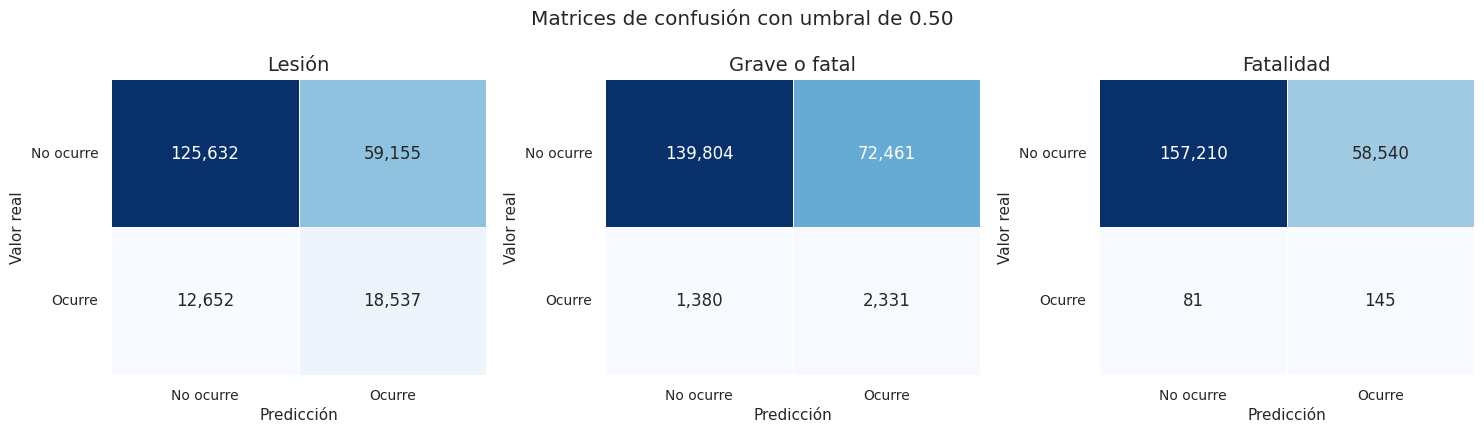

In [84]:
phase3_confusion_labels = ["No ocurre", "Ocurre"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

for ax, (outcome, label) in zip(axes, phase3_labels.items()):
    split = phase3_splits[outcome]
    matrix = confusion_matrix(
        split["y_test"],
        split["prediction"],
        labels=[0, 1],
    )
    sns.heatmap(
        matrix,
        annot=True,
        fmt=",d",
        cmap="Blues",
        cbar=False,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Valor real")
    ax.set_xticklabels(phase3_confusion_labels)
    ax.set_yticklabels(phase3_confusion_labels, rotation=0)

fig.suptitle("Matrices de confusión con umbral de 0.50")
fig.tight_layout()
plt.show()

### Interpretación de las matrices de confusión

Cada matriz cruza el valor real del accidente con la predicción del modelo usando un umbral de 0.50. Las filas representan el valor observado y las columnas la clasificación predicha:

- **Verdadero negativo:** el accidente no tenía el evento y el modelo lo identificó como negativo.
- **Falso positivo:** el modelo señaló el evento, pero el registro no lo presentaba.
- **Falso negativo:** el accidente sí tenía el evento, pero el modelo no lo detectó.
- **Verdadero positivo:** el modelo detectó correctamente el evento.

El gráfico muestra cantidades absolutas, por lo que el tamaño de la clase negativa domina visualmente, especialmente en fatalidades. Para comparar resultados de distinta prevalencia se deben complementar esas cantidades con recall, precision, F1 y PR-AUC, que aparecen en la tabla anterior.

El uso de `class_weight="balanced"` busca aumentar la detección de positivos y normalmente eleva el recall respecto a un modelo que ignorara la clase minoritaria. El costo es un aumento de falsos positivos, que se refleja en las precision bajas de los resultados raros. En términos prácticos, el modelo puede ser útil para generar una lista de accidentes que merecen revisión, pero no para afirmar automáticamente que cada caso señalado tendrá una fatalidad o lesión grave.

La matriz también hace visible por qué la accuracy no basta. Aunque la mayoría de los accidentes no registra fatalidades, acertar esos negativos no demuestra que el modelo encuentre bien los pocos casos positivos. La evaluación debe centrarse en el equilibrio entre falsos negativos y falsos positivos según el objetivo del análisis.

## Alcance y limitaciones de la Fase 3

Esta fase documenta un flujo completo de modelado supervisado: definición de eventos, selección de predictores, prevención de fuga de información, transformación de variables, división estratificada, entrenamiento, evaluación y explicación mediante odds ratios. El modelo trabaja sobre el extracto Gold y, por tanto, aprovecha la separación entre la preparación estructural gestionada por dbt y el análisis estadístico del notebook.

El resultado debe entenderse como un modelo exploratorio y educativo, no como un sistema de alerta en producción. Existen varias razones:

- El dataset registra accidentes ocurridos, no todos los desplazamientos ni la exposición al tráfico. Por ello no permite estimar directamente el riesgo de que una persona tenga un accidente bajo una condición determinada.
- La información puede contener subnotificación, cambios en los procedimientos de registro y variables no observadas, como volumen de tráfico, velocidad real, estado del vehículo o características del conductor.
- La relación es observacional. Un odds ratio ajustado no demuestra causalidad y puede cambiar si se incorporan nuevos predictores o se modifica la definición de los eventos.
- La división aleatoria conserva la prevalencia, pero no prueba el comportamiento frente a años futuros. Una validación temporal sería más apropiada para medir estabilidad ante cambios de distribución.
- El balanceo de clases ayuda a clasificar eventos raros, pero modifica la escala de las probabilidades. Para usar estas salidas como probabilidades operativas habría que calibrarlas y evaluar Brier score o curvas de calibración.
- Los coeficientes presentados no incluyen todavía intervalos de confianza ni pruebas de significancia. Las conclusiones sobre magnitud son descriptivas y deben contrastarse con análisis de sensibilidad.

Una evolución natural sería seleccionar umbrales según el costo de los errores, realizar validación temporal, calibrar las probabilidades, calcular intervalos de confianza para los coeficientes y comparar la regresión logística con modelos de conteo para el número de lesiones. Estas mejoras permitirían pasar de una primera modelización explicativa a una evaluación más sólida y cercana a un caso de uso real.

# Fase 4 — Análisis temporal y geográfico

Esta fase completa la extensión analítica incorporando dos dimensiones que ayudan a contextualizar los accidentes: **cuándo** ocurren y **dónde** se concentran. Hasta ahora el notebook describió distribuciones, comparó grupos, calculó intervalos de confianza y ajustó modelos logísticos. Aquí se estudia la evolución temporal y se utiliza la información geográfica disponible en Gold para localizar concentraciones descriptivas.

El análisis temporal trabaja con fechas y horas del accidente. El análisis geográfico utiliza latitud, longitud, nombre de calle y distrito policial cuando están disponibles. Las coordenadas y los nombres de calles se filtran únicamente para construir estas visualizaciones; no se eliminan del warehouse ni se modifica el dataset fuente.

Una concentración de registros no equivale automáticamente a una mayor peligrosidad. Para afirmar riesgo sería necesario incorporar exposición —por ejemplo, volumen de tráfico, población, longitud de la vía o número de desplazamientos—. Por ello, los resultados de esta fase se presentan como frecuencias y proporciones observadas dentro de los accidentes registrados.

## 1. Preparación del análisis temporal

La fecha del accidente permite construir una serie anual y un perfil mensual. La tabla anual contará los accidentes y calculará proporciones observadas de lesiones, consecuencias graves o fatales y fatalidades. Estas proporciones no son tasas de riesgo poblacional: el denominador es el número de accidentes registrados en ese año.

Además de observar cuántos accidentes aparecen por año, interesa separar dos preguntas distintas:

1. ¿Cambió el volumen de accidentes registrados?
2. ¿Cambió la composición de sus consecuencias?

Un año puede tener menos registros, pero una proporción mayor de accidentes con lesiones. Por eso se muestran los conteos y las proporciones en columnas distintas.

In [85]:
phase4_temporal = analysis.copy()
phase4_temporal["CRASH_DATE"] = pd.to_datetime(
    phase4_temporal["CRASH_DATE"], errors="coerce"
)
phase4_temporal = phase4_temporal.dropna(subset=["CRASH_DATE"]).copy()
phase4_temporal["year"] = phase4_temporal["CRASH_DATE"].dt.year.astype(int)
phase4_temporal["month"] = phase4_temporal["CRASH_DATE"].dt.month.astype(int)

annual_summary = (
    phase4_temporal.groupby("year", as_index=False)
    .agg(
        Accidentes=("CRASH_RECORD_ID", "count"),
        Con_lesiones=("has_injury", "sum"),
        Graves_o_fatales=("is_severe", "sum"),
        Fatales=("is_fatal", "sum"),
    )
    .sort_values("year")
)
annual_summary["Proporción con lesiones (%)"] = (
    annual_summary["Con_lesiones"] / annual_summary["Accidentes"] * 100
)
annual_summary["Proporción grave o fatal (%)"] = (
    annual_summary["Graves_o_fatales"] / annual_summary["Accidentes"] * 100
)
annual_summary["Proporción fatal (%)"] = (
    annual_summary["Fatales"] / annual_summary["Accidentes"] * 100
)

print(
    "Cobertura temporal:",
    phase4_temporal["CRASH_DATE"].min().date(),
    "a",
    phase4_temporal["CRASH_DATE"].max().date(),
)
annual_summary.style.format({
    "Accidentes": "{:,.0f}",
    "Con_lesiones": "{:,.0f}",
    "Graves_o_fatales": "{:,.0f}",
    "Fatales": "{:,.0f}",
    "Proporción con lesiones (%)": "{:.2f}%",
    "Proporción grave o fatal (%)": "{:.2f}%",
    "Proporción fatal (%)": "{:.2f}%",
})

Cobertura temporal: 2013-03-03 a 2026-07-31


,year,Accidentes,Con_lesiones,Graves_o_fatales,Fatales,Proporción con lesiones (%),Proporción grave o fatal (%),Proporción fatal (%)
0,2013,2,2,0,0,100.00%,0.00%,0.00%
1,2014,6,1,0,0,16.67%,0.00%,0.00%
2,2015,"9,834",526,54,3,5.35%,0.55%,0.03%
3,2016,"44,297","2,669",291,14,6.03%,0.66%,0.03%
4,2017,"83,786","9,642","1,331",78,11.51%,1.59%,0.09%
5,2018,"118,952","16,586","2,255",114,13.94%,1.90%,0.10%
6,2019,"117,764","16,315","2,113",102,13.85%,1.79%,0.09%
7,2020,"92,096","14,166","2,022",134,15.38%,2.20%,0.15%
8,2021,"108,767","16,331","2,187",156,15.01%,2.01%,0.14%
9,2022,"108,412","16,034","2,093",135,14.79%,1.93%,0.12%


### Interpretación de la tabla anual

Cada fila representa un año y conserva el grano de accidente para contar registros. **Accidentes** mide el volumen observado; las columnas de consecuencias cuentan cuántos registros de ese año tienen al menos una lesión, una consecuencia grave o fatalidad. Las tres columnas de proporción dividen esos conteos por los accidentes del mismo año, de modo que permiten comparar la composición de años con distinto tamaño.

Si el número de accidentes sube o baja, eso describe el comportamiento del registro administrativo, pero no necesariamente el número real de colisiones en la ciudad. De igual manera, una proporción anual mayor de lesiones puede deberse a cambios en la gravedad de los accidentes registrados, en la cobertura del reporte o en la composición de los casos. La tabla es útil para detectar años que merecen investigación adicional y para construir indicadores de seguimiento, pero no basta para concluir que existe una tendencia causal.

También es importante revisar la cobertura antes de comparar años: en esta ejecución los primeros años tienen pocos registros y 2026 solo llega hasta el 31 de julio. Esos periodos no son comparables con años completos y pueden distorsionar cualquier tendencia. Las comparaciones más estables deberían concentrarse en años completos o etiquetar explícitamente los periodos parciales.

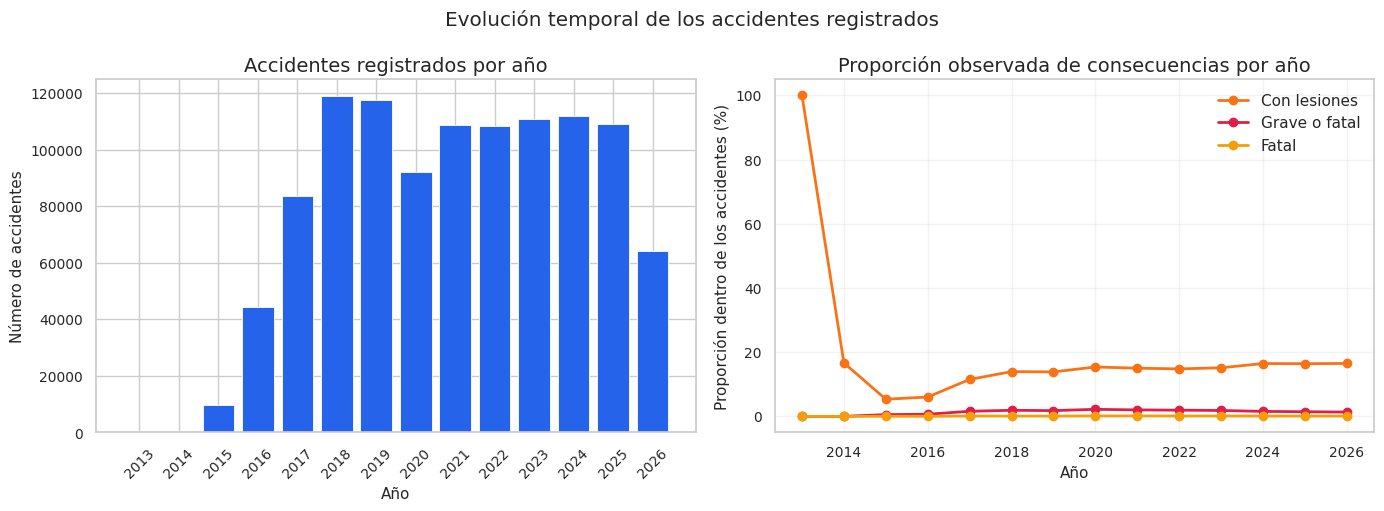

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

axes[0].bar(
    annual_summary["year"].astype(str),
    annual_summary["Accidentes"],
    color=PALETTE[0],
    edgecolor="white",
    linewidth=0.6,
)
axes[0].set_title("Accidentes registrados por año")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("Número de accidentes")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    annual_summary["year"],
    annual_summary["Proporción con lesiones (%)"],
    marker="o",
    linewidth=2,
    color=PALETTE[1],
    label="Con lesiones",
)
axes[1].plot(
    annual_summary["year"],
    annual_summary["Proporción grave o fatal (%)"],
    marker="o",
    linewidth=2,
    color=PALETTE[4],
    label="Grave o fatal",
)
axes[1].plot(
    annual_summary["year"],
    annual_summary["Proporción fatal (%)"],
    marker="o",
    linewidth=2,
    color=PALETTE[6],
    label="Fatal",
)
axes[1].set_title("Proporción observada de consecuencias por año")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Proporción dentro de los accidentes (%)")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle("Evolución temporal de los accidentes registrados")
fig.tight_layout()
plt.show()

### Interpretación de la evolución anual

El panel izquierdo responde cuánto se registró en cada año; el panel derecho responde qué composición tuvieron esos registros. Leer ambos paneles juntos evita confundir volumen con severidad. Por ejemplo, un aumento de accidentes acompañado por una proporción estable de lesiones representa una situación distinta de un aumento simultáneo del volumen y de la proporción de consecuencias.

Las líneas de consecuencias graves y fatales suelen moverse en una escala mucho menor que la línea de lesiones. Esa diferencia de escala es informativa: muestra que la mayoría de los accidentes con consecuencias no terminan en fatalidad, pero también recuerda que un pequeño cambio absoluto en fatalidades puede producir una variación visible cuando el denominador es grande o el evento es muy raro. La gráfica permite identificar cambios y años atípicos; la explicación de esos cambios requeriría contrastar políticas, movilidad, cobertura del reporte y otras fuentes externas.

## 2. Estacionalidad mensual

El perfil mensual agrupa todos los años para observar si ciertos meses concentran más registros o presentan una composición diferente de consecuencias. Agrupar los años ayuda a obtener una visión general de la estacionalidad, pero también oculta cambios específicos de cada año. Por esa razón, este resultado debe complementarse con la tabla anual y no sustituirla.

In [87]:
month_names_es = {
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre",
}

monthly_summary = (
    phase4_temporal.groupby("month", as_index=False)
    .agg(
        Accidentes=("CRASH_RECORD_ID", "count"),
        Con_lesiones=("has_injury", "sum"),
        Graves_o_fatales=("is_severe", "sum"),
        Fatales=("is_fatal", "sum"),
    )
    .set_index("month")
    .reindex(range(1, 13), fill_value=0)
    .reset_index()
)
monthly_summary["Mes"] = monthly_summary["month"].map(month_names_es)
monthly_summary["Proporción con lesiones (%)"] = (
    monthly_summary["Con_lesiones"] / monthly_summary["Accidentes"] * 100
)
monthly_summary["Proporción grave o fatal (%)"] = (
    monthly_summary["Graves_o_fatales"] / monthly_summary["Accidentes"] * 100
)
monthly_summary["Proporción fatal (%)"] = (
    monthly_summary["Fatales"] / monthly_summary["Accidentes"] * 100
)

monthly_summary[[
    "Mes",
    "Accidentes",
    "Con_lesiones",
    "Graves_o_fatales",
    "Fatales",
    "Proporción con lesiones (%)",
    "Proporción grave o fatal (%)",
    "Proporción fatal (%)",
]].style.format({
    "Accidentes": "{:,.0f}",
    "Con_lesiones": "{:,.0f}",
    "Graves_o_fatales": "{:,.0f}",
    "Fatales": "{:,.0f}",
    "Proporción con lesiones (%)": "{:.2f}%",
    "Proporción grave o fatal (%)": "{:.2f}%",
    "Proporción fatal (%)": "{:.2f}%",
})

,Mes,Accidentes,Con_lesiones,Graves_o_fatales,Fatales,Proporción con lesiones (%),Proporción grave o fatal (%),Proporción fatal (%)
0,Enero,"83,759","11,000","1,202",84,13.13%,1.44%,0.10%
1,Febrero,"80,875","10,023","1,120",66,12.39%,1.38%,0.08%
2,Marzo,"85,234","11,547","1,333",85,13.55%,1.56%,0.10%
3,Abril,"84,310","11,872","1,352",77,14.08%,1.60%,0.09%
4,Mayo,"97,375","14,487","1,714",97,14.88%,1.76%,0.10%
5,Junio,"97,613","14,916","1,811",98,15.28%,1.86%,0.10%
6,Julio,"97,689","15,468","1,945",132,15.83%,1.99%,0.14%
7,Agosto,"91,024","14,118","1,773",104,15.51%,1.95%,0.11%
8,Septiembre,"91,277","14,090","1,754",106,15.44%,1.92%,0.12%
9,Octubre,"95,747","14,414","1,705",97,15.05%,1.78%,0.10%


### Interpretación de la tabla mensual

La tabla permite comparar meses usando el mismo conjunto de indicadores que la tabla anual. El conteo identifica meses con mayor volumen de accidentes registrados y las proporciones permiten comprobar si ese volumen viene acompañado de una composición más o menos severa.

Una diferencia mensual puede estar asociada con clima, horas de luz, vacaciones, movilidad o cambios en la exposición al tráfico. Sin información del número de viajes realizados en cada mes no es correcto llamar “más riesgoso” a un mes solo porque acumula más accidentes. El valor de esta tabla es descriptivo y sirve para orientar preguntas posteriores o filtros de un dashboard.

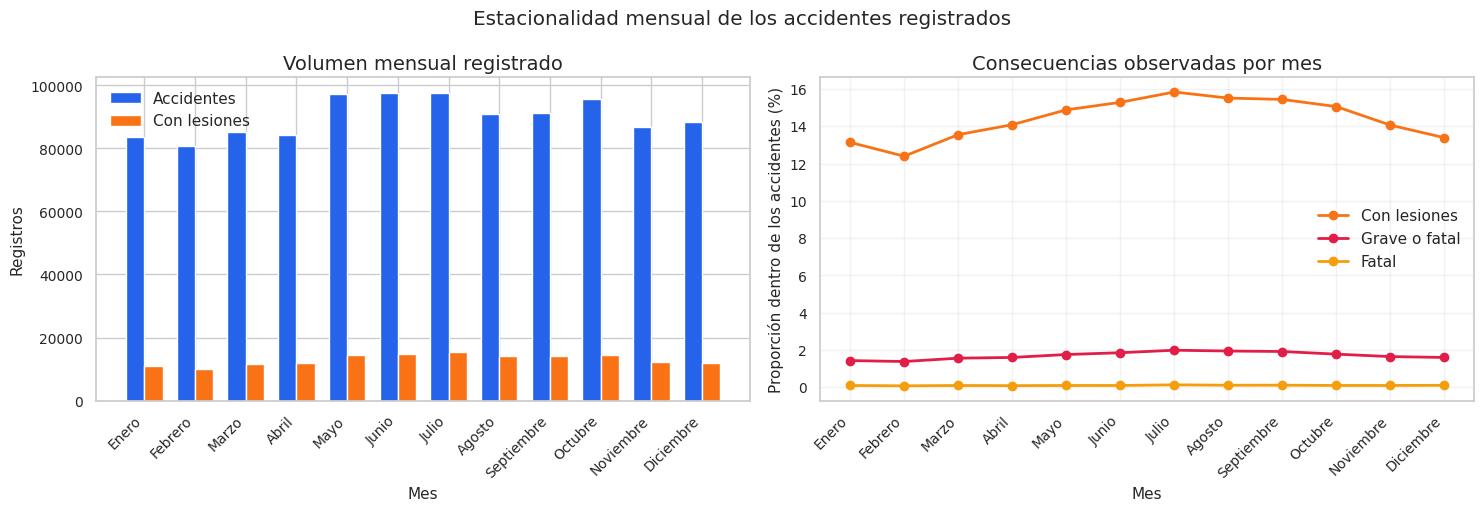

In [88]:
month_labels = monthly_summary["Mes"]
x = np.arange(len(month_labels))
width = 0.36

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
axes[0].bar(
    x - width / 2,
    monthly_summary["Accidentes"],
    width,
    color=PALETTE[0],
    label="Accidentes",
)
axes[0].bar(
    x + width / 2,
    monthly_summary["Con_lesiones"],
    width,
    color=PALETTE[1],
    label="Con lesiones",
)
axes[0].set_title("Volumen mensual registrado")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Registros")
axes[0].set_xticks(x)
axes[0].set_xticklabels(month_labels, rotation=45, ha="right")
axes[0].legend()

axes[1].plot(
    x,
    monthly_summary["Proporción con lesiones (%)"],
    marker="o",
    color=PALETTE[1],
    linewidth=2,
    label="Con lesiones",
)
axes[1].plot(
    x,
    monthly_summary["Proporción grave o fatal (%)"],
    marker="o",
    color=PALETTE[4],
    linewidth=2,
    label="Grave o fatal",
)
axes[1].plot(
    x,
    monthly_summary["Proporción fatal (%)"],
    marker="o",
    color=PALETTE[6],
    linewidth=2,
    label="Fatal",
)
axes[1].set_title("Consecuencias observadas por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Proporción dentro de los accidentes (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_labels, rotation=45, ha="right")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.suptitle("Estacionalidad mensual de los accidentes registrados")
fig.tight_layout()
plt.show()

### Interpretación del patrón mensual

El primer panel compara el volumen total con el número de accidentes que registran lesiones. El segundo panel normaliza por el volumen mensual y permite distinguir meses con una composición diferente. La separación entre ambos paneles es importante: el mes con más accidentes no tiene por qué ser el mes con mayor proporción de lesiones.

Este gráfico puede convertirse en una dimensión útil para Power BI, por ejemplo mediante filtros de año, mes y severidad. Sin embargo, para afirmar una estacionalidad estadísticamente estable sería necesario estudiar la variabilidad de cada mes entre años y calcular intervalos de confianza o modelos que controlen tendencias temporales.

## 3. Preparación del análisis geográfico

El modelo Gold conserva latitud, longitud, nombre de calle y beat policial. Para el análisis espacial se consideran coordenadas no nulas dentro de un rango amplio de Chicago: latitud entre 41 y 43 grados norte y longitud entre -88 y -87 grados oeste. Este filtro replica el control de plausibilidad utilizado en la validación del warehouse.

Los registros sin coordenadas no se eliminan del análisis general; simplemente no pueden ubicarse en un gráfico espacial. De la misma manera, los nombres de calles faltantes no se convierten artificialmente en una calle real. La cobertura geográfica debe medirse antes de interpretar cualquier concentración.

In [89]:
phase4_geo = analysis[[
    "CRASH_RECORD_ID",
    "LATITUDE",
    "LONGITUDE",
    "STREET_NAME",
    "BEAT_OF_OCCURRENCE",
    "has_injury",
    "is_severe",
    "is_fatal",
]].copy()
phase4_geo["LATITUDE"] = pd.to_numeric(
    phase4_geo["LATITUDE"], errors="coerce"
)
phase4_geo["LONGITUDE"] = pd.to_numeric(
    phase4_geo["LONGITUDE"], errors="coerce"
)

valid_geo = phase4_geo[
    phase4_geo["LATITUDE"].between(41, 43)
    & phase4_geo["LONGITUDE"].between(-88, -87)
].copy()
valid_geo["STREET_NAME"] = (
    valid_geo["STREET_NAME"]
    .astype("string")
    .str.strip()
    .str.upper()
)

geo_summary = pd.DataFrame({
    "Métrica": [
        "Registros totales",
        "Registros con coordenadas válidas",
        "Cobertura geográfica (%)",
        "Registros con nombre de calle",
        "Beats policiales disponibles",
    ],
    "Valor": [
        len(phase4_geo),
        len(valid_geo),
        len(valid_geo) / len(phase4_geo) * 100,
        int(valid_geo["STREET_NAME"].notna().sum()),
        int(valid_geo["BEAT_OF_OCCURRENCE"].notna().sum()),
    ],
})
geo_summary.style.format({
    "Valor": lambda value: f"{value:,.2f}" if isinstance(value, float) else f"{value:,}"
})

,Métrica,Valor
0,Registros totales,"1,079,880.00"
1,Registros con coordenadas válidas,"1,071,405.00"
2,Cobertura geográfica (%),99.22
3,Registros con nombre de calle,"1,071,405.00"
4,Beats policiales disponibles,"1,071,402.00"


### Interpretación de la cobertura geográfica

Esta tabla responde primero si el análisis espacial es confiable como descripción de la muestra. La cantidad de coordenadas válidas indica cuántos accidentes pueden ubicarse; la cobertura geográfica expresa qué porcentaje del extracto total representa. Los registros sin coordenadas siguen siendo válidos para el análisis temporal, de severidad y de frecuencia, pero quedan fuera de las visualizaciones espaciales.

La disponibilidad de nombres de calles y beats también limita el nivel de detalle. Un nombre de calle sirve para contar registros, mientras que un beat permite agrupar por una zona policial. Ninguna de las dos variables, por sí sola, mide exposición ni longitud de la vía. La tabla de cobertura es por tanto una condición previa para no presentar un mapa como si representara la totalidad de los accidentes.

In [90]:
street_data = valid_geo[
    valid_geo["STREET_NAME"].notna()
    & ~valid_geo["STREET_NAME"].isin([
        "",
        "UNKNOWN",
        "NOT REPORTED",
        "NOT APPLICABLE",
    ])
].copy()

street_summary = (
    street_data.groupby("STREET_NAME", as_index=False)
    .agg(
        Accidentes=("CRASH_RECORD_ID", "count"),
        **{
            "Proporción con lesiones (%)": ("has_injury", "mean"),
            "Proporción grave o fatal (%)": ("is_severe", "mean"),
            "Proporción fatal (%)": ("is_fatal", "mean"),
        },
    )
)
for column in [
    "Proporción con lesiones (%)",
    "Proporción grave o fatal (%)",
    "Proporción fatal (%)",
]:
    street_summary[column] = street_summary[column] * 100

top_streets = (
    street_summary[street_summary["Accidentes"] >= 500]
    .sort_values("Accidentes", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
top_streets.style.format({
    "Accidentes": "{:,.0f}",
    "Proporción con lesiones (%)": "{:.2f}%",
    "Proporción grave o fatal (%)": "{:.2f}%",
    "Proporción fatal (%)": "{:.2f}%",
})

,STREET_NAME,Accidentes,Proporción con lesiones (%),Proporción grave o fatal (%),Proporción fatal (%)
0,WESTERN AVE,"29,552",14.99%,1.72%,0.11%
1,PULASKI RD,"25,802",16.33%,2.09%,0.14%
2,CICERO AVE,"24,236",15.40%,1.92%,0.14%
3,ASHLAND AVE,"23,374",16.36%,1.96%,0.15%
4,HALSTED ST,"20,578",18.25%,2.15%,0.18%
5,KEDZIE AVE,"18,984",15.11%,1.59%,0.10%
6,MICHIGAN AVE,"13,819",14.60%,1.72%,0.06%
7,NORTH AVE,"12,501",14.86%,1.70%,0.13%
8,STATE ST,"11,983",17.51%,2.07%,0.13%
9,CLARK ST,"11,564",14.34%,1.45%,0.03%


### Interpretación de las calles con más registros

La tabla ordena las calles por número de accidentes registrados y muestra, además, la proporción observada de lesiones, consecuencias graves o fatales y fatalidades dentro de cada calle. El umbral mínimo de 500 registros evita comparar tasas de una calle con cientos de observaciones contra otra con muy pocos casos, aunque no elimina completamente la incertidumbre.

Las calles con mayor frecuencia suelen combinar movilidad, longitud, intersecciones y volumen de tráfico. Por eso “más accidentes registrados” no significa automáticamente “más peligrosa”. La tabla sirve para priorizar investigación, enriquecer un dashboard y detectar lugares que requieren contexto adicional. Para comparar peligrosidad de forma justa habría que dividir por exposición, como vehículos que circulan por la calle o kilómetros recorridos, y aplicar intervalos de confianza a las proporciones.

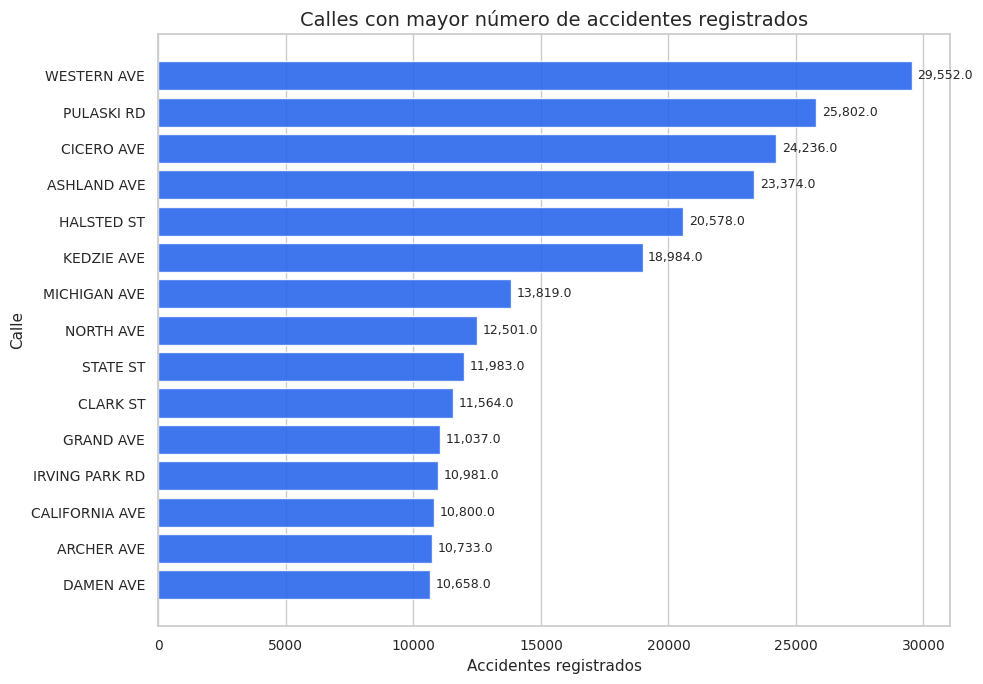

In [91]:
streets_plot = top_streets.sort_values("Accidentes", ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    streets_plot["STREET_NAME"],
    streets_plot["Accidentes"],
    color=PALETTE[0],
    alpha=0.88,
)
ax.bar_label(bars, fmt="{:,}", padding=4, fontsize=9)
ax.set_title("Calles con mayor número de accidentes registrados")
ax.set_xlabel("Accidentes registrados")
ax.set_ylabel("Calle")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

### Interpretación del gráfico de calles

El gráfico facilita comparar rápidamente el volumen de registros entre las principales calles. La orientación horizontal mantiene legibles los nombres y las etiquetas permiten leer los conteos sin depender únicamente de la longitud de la barra.

Esta visualización es apropiada para una pregunta de frecuencia —“¿en qué calles aparecen más registros?”—, no para una pregunta causal o de riesgo. Una calle extensa y muy transitada puede acumular más accidentes simplemente porque tiene mayor exposición. La lectura profesional consiste en usar este resultado como mapa de priorización y combinarlo con volumen de tráfico, longitud, infraestructura y severidad.

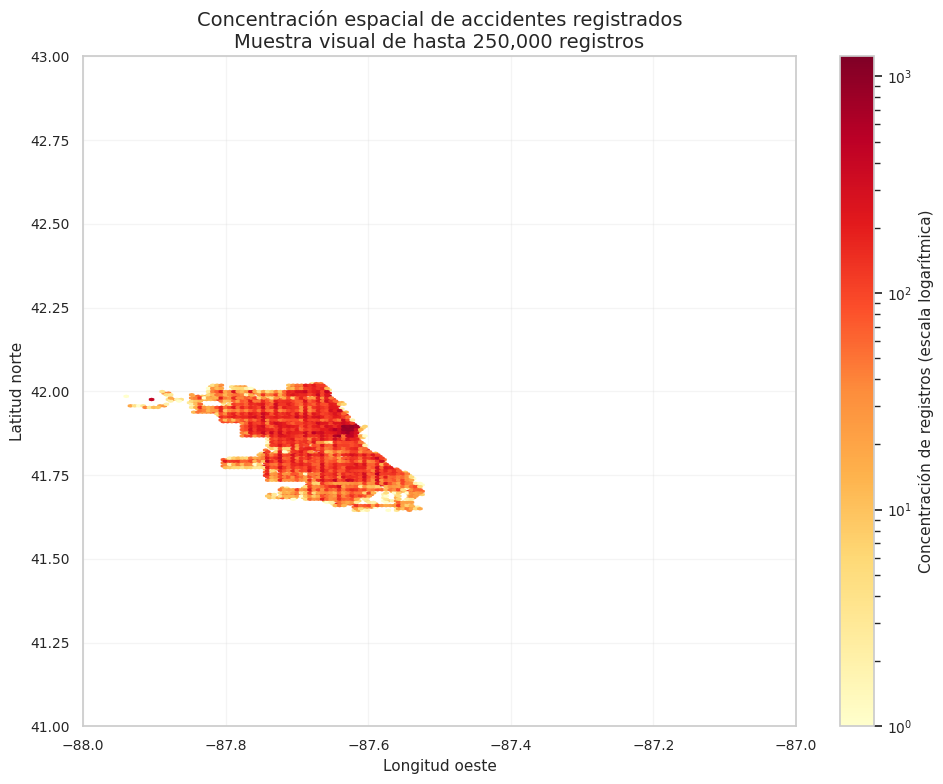

In [92]:
geo_sample = valid_geo.sample(
    n=min(250_000, len(valid_geo)),
    random_state=42,
)

fig, ax = plt.subplots(figsize=(10, 8))
hexbin = ax.hexbin(
    geo_sample["LONGITUDE"],
    geo_sample["LATITUDE"],
    gridsize=70,
    mincnt=1,
    bins="log",
    cmap="YlOrRd",
)
colorbar = fig.colorbar(hexbin, ax=ax)
colorbar.set_label("Concentración de registros (escala logarítmica)")
ax.set_xlim(-88, -87)
ax.set_ylim(41, 43)
ax.set_xlabel("Longitud oeste")
ax.set_ylabel("Latitud norte")
ax.set_title(
    "Concentración espacial de accidentes registrados\n"
    "Muestra visual de hasta 250,000 registros"
)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

### Interpretación de la concentración espacial

El hexbin divide el plano de coordenadas en celdas y colorea cada celda según el número de registros que cae dentro de ella. La escala logarítmica permite visualizar simultáneamente zonas con mucha y poca concentración; no significa que el mapa muestre una probabilidad logarítmica.

Para que el gráfico sea manejable se utiliza una muestra reproducible de hasta 250,000 registros, mientras que las tablas de cobertura y calles se calculan con todos los registros geográficos válidos. Las zonas más oscuras concentran más accidentes registrados en términos absolutos, pero pueden corresponder a áreas con más tráfico, más intersecciones o mayor cobertura de reporte. Sin una capa de calles, límites administrativos y exposición al tráfico, este gráfico debe leerse como una vista exploratoria de densidad, no como un mapa de riesgo.

## Lectura ejecutiva de la Fase 4

La Fase 4 añade contexto temporal y geográfico al proyecto. Las tablas y gráficos anuales permiten separar volumen de composición; el perfil mensual muestra patrones de estacionalidad; la tabla de cobertura verifica qué parte de los datos puede ubicarse; y los análisis por calle y hexbin muestran dónde se concentran los registros disponibles.

La principal conclusión metodológica es que frecuencia, proporción y riesgo no son sinónimos. El notebook puede describir cuándo y dónde aparecen más accidentes, pero no puede medir riesgo poblacional sin información de exposición. Esta distinción evita convertir una visualización descriptiva en una afirmación causal.

## Cierre final del proyecto

### Alcance alcanzado

El proyecto evolucionó desde un notebook de estadística descriptiva sobre un CSV hasta un flujo analítico conectado a un warehouse en BigQuery. La arquitectura actual conserva el dato raw en Cloud Storage y BigQuery, aplica limpieza, tipado, validaciones y modelado dimensional mediante dbt, y utiliza la capa Gold como fuente del notebook y de futuros consumidores de Business Intelligence.

Sobre ese fundamento se desarrollaron cuatro niveles de análisis:

- **Análisis descriptivo:** distribuciones, tablas de frecuencia, medidas estadísticas y visualizaciones de accidentes, lesiones, clima, iluminación, infraestructura y severidad.
- **Probabilidad e inferencia:** probabilidades simples y condicionales, distribuciones discretas, riesgo relativo, odds ratio, pruebas chi-cuadrado, V de Cramér e intervalos de confianza.
- **Modelado estadístico:** regresiones logísticas multivariables para lesiones, consecuencias graves y fatalidades, con separación entrenamiento/prueba, métricas de clasificación, curvas ROC y Precision-Recall, matrices de confusión y odds ratios.
- **Análisis temporal y geográfico:** evolución anual, estacionalidad mensual, cobertura de coordenadas, concentración espacial y calles con mayor frecuencia de registros.

### Qué puede afirmarse con estos resultados

El notebook caracteriza patrones dentro de los accidentes reportados y muestra cómo pasar de una pregunta descriptiva a una comparación inferencial y después a un modelo multivariable. También evidencia que una relación estadísticamente detectable no necesariamente es grande, causal o útil para predecir individualmente. Los resultados son adecuados para priorizar preguntas, diseñar visualizaciones y demostrar un flujo reproducible de análisis estadístico sobre datos reales.

No es válido afirmar que una condición “causa” un accidente, que una calle es objetivamente más peligrosa solo porque tiene más registros o que una probabilidad calculada sobre accidentes equivale al riesgo de un conductor. El dataset no contiene toda la exposición al tráfico ni todos los factores que influyen en un accidente.

### Mejoras y futuras ampliaciones

- Construir el dashboard de Power BI sobre `mart_crashes_daily`, `mart_severity_summary`, `mart_risk_factors` y dimensiones Gold, usando medidas DAX para indicadores ejecutivos.
- Incorporar validación temporal y calibración de probabilidades para evaluar si los modelos mantienen su desempeño en años posteriores.
- Añadir intervalos de confianza, pruebas de sensibilidad y selección de umbral según el costo de falsos positivos y falsos negativos.
- Comparar la regresión logística con modelos de conteo Poisson, binomial negativa o modelos con exceso de ceros para el número de lesiones.
- Enriquecer el análisis geográfico con límites administrativos, red vial, volumen de tráfico, población y kilómetros recorridos para aproximar tasas de riesgo.
- Evolucionar el warehouse hacia cargas incrementales, particionamiento, monitoreo de frescura y pruebas automatizadas en CI/CD.
- Documentar un flujo de actualización reproducible que ejecute la ingesta, dbt, validaciones, extracción analítica y refresco del dashboard.

En conjunto, el proyecto demuestra competencias de ingeniería de datos, SQL y BigQuery, transformación con dbt, análisis con Python, estadística descriptiva e inferencial, modelado predictivo y comunicación de resultados. Su siguiente paso natural es conectar esta base analítica con un producto BI bien diseñado y con una evaluación temporal más rigurosa.